## Windkessel-Informed Neural Network for Cuffless BP Estimation 
==========================================================================

Physics constraint: 2-element Windkessel diastolic decay equation
 ##   DBP = SBP * exp(-decay_time / RC) ##
 
This constrains DBP to be consistent with the model's own SBP prediction
and the measured diastolic decay time (systolic peak -> dicrotic notch).
SBP remains purely data-driven (see explanation in accompanying chat message).
 
Sections:

    -  Peak / dicrotic notch detection  (feature extraction from raw PPG)

    -  RC estimation                    (fit once from training data)

    -  Windkessel physics loss          (the actual PINN constraint)

    - Model architecture               (simple 1D CNN)

    - Training loop                    (combines data loss + physics loss)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import (
    find_peaks,
    savgol_filter
)
import h5py

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from torch.utils.data import Dataset, DataLoader

import sys
sys.path.append("..") 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Peak / Dicrotic Notch detection ##

Systolic peak = start of the "pressure is falling" phase, and dicrotic notch = the precise physiological start of diastole, where the heart is no longer pushing anything in.

For this eqn - P(t) = P_sys · exp(-t / RC)

We need t = decay time, which is simply the number of seconds it takes for arterial pressure to go from its systolic peak down to the start of the diastolic (passive) phase, measured as the time gap between the systolic peak and the dicrotic notch on the PPG waveform.

In [2]:
from PINN import prepare_UCI_dataset_w, get_dicrotic_notch, get_systolic_peak, get_delay_time, estimate_RC, grid_search_RC, train_resnet1d, create_data_loaders, run_windkessel_pinn, plot_training_loss,plot_pinn_training_metrics

In [11]:
wavelet = "db4"
level = 7
DATA_PATH = (f"/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/PINN/wavelets_data/{wavelet}_{level}")

MAT_PATH = f"/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/PINN/wavelets_data/{wavelet}_{level}/Part_1.mat"

In [12]:
FS = 125
WINDOW_SIZE = 1000


f = h5py.File(MAT_PATH, "r")

dataset = f["Part_1"]

# print("Number of recordings:", dataset.shape[0])
ref = dataset[1,0 ]

recording = f[ref][:]

print("Recording shape:", recording.shape)
ppg = recording[:, 0]
abp = recording[:, 1]

print("PPG length:", len(ppg))
print("ABP length:", len(abp))
ppg_std = np.std(ppg)


ppg = (ppg - np.mean(ppg)) / ppg_std # Normalize PPG signal
START = 0

ppg_window = ppg[
    START:START + WINDOW_SIZE
]

print("Window shape:", ppg_window.shape)


# ==========================================
# Detect ALL systolic peaks
# ==========================================

sys_peaks = get_systolic_peak(
    ppg_window,
    FS
)

print(
    "Number of systolic peaks:",
    len(sys_peaks)
)

print(
    "Systolic peak indices:",
    sys_peaks
)


# ==========================================
# Find notch after EACH systolic peak
# ==========================================
def calculate_derivatives(ppg, fs=125):

    # -----------------------------------
    # Smooth PPG
    # -----------------------------------

    smooth_ppg = savgol_filter(
        ppg,
        window_length=15,
        polyorder=3
    )

    # -----------------------------------
    # First derivative = VPG
    # -----------------------------------

    vpg = np.gradient(
        smooth_ppg
    ) * fs

    # -----------------------------------
    # Second derivative = APG
    # -----------------------------------

    apg = np.gradient(
        vpg
    ) * fs

    return smooth_ppg, vpg, apg
notches = []

for sys_idx in sys_peaks:
    smooth_ppg, vpg, apg = calculate_derivatives(
            ppg_window,
            FS
        )
    

    notch_idx = get_dicrotic_notch(
        ppg_window,
        sys_idx,
        vpg,
        apg,
        FS
    )

    notches.append(notch_idx)


# ==========================================
# Print results
# ==========================================

print("\nDetected landmarks:")

for i, (sys_idx, notch_idx) in enumerate(
    zip(sys_peaks, notches)
):

    print(
        f"Beat {i+1}: "
        f"Systolic = {sys_idx} "
        f"({sys_idx / FS:.3f} s), "
        f"Notch = {notch_idx}"
    )


delay_times = []

for sys_idx, notch_idx in zip(
    sys_peaks,
    notches
):

    if notch_idx is None:
        delay_times.append(np.nan)

    else:

        delay = (
            notch_idx - sys_idx
        ) / FS

        delay_times.append(delay)


delay_times = np.array(
    delay_times,
    dtype=np.float32
)


print("\nPeak → notch delays:")

for i, delay in enumerate(delay_times):

    if np.isnan(delay):

        print(
            f"Beat {i+1}: Detection failed"
        )

    else:

        print(
            f"Beat {i+1}: "
            f"{delay:.3f} seconds"
        )


Recording shape: (61000, 3)
PPG length: 61000
ABP length: 61000
Window shape: (1000,)
Number of systolic peaks: 15
Systolic peak indices: [ 54 119 184 249 312 377 442 507 569 633 698 761 824 886 950]

Detected landmarks:
Beat 1: Systolic = 54 (0.432 s), Notch = 74
Beat 2: Systolic = 119 (0.952 s), Notch = 138
Beat 3: Systolic = 184 (1.472 s), Notch = 203
Beat 4: Systolic = 249 (1.992 s), Notch = 267
Beat 5: Systolic = 312 (2.496 s), Notch = 333
Beat 6: Systolic = 377 (3.016 s), Notch = 397
Beat 7: Systolic = 442 (3.536 s), Notch = 461
Beat 8: Systolic = 507 (4.056 s), Notch = 526
Beat 9: Systolic = 569 (4.552 s), Notch = 588
Beat 10: Systolic = 633 (5.064 s), Notch = 652
Beat 11: Systolic = 698 (5.584 s), Notch = 717
Beat 12: Systolic = 761 (6.088 s), Notch = 783
Beat 13: Systolic = 824 (6.592 s), Notch = 844
Beat 14: Systolic = 886 (7.088 s), Notch = 907
Beat 15: Systolic = 950 (7.600 s), Notch = 970

Peak → notch delays:
Beat 1: 0.160 seconds
Beat 2: 0.152 seconds
Beat 3: 0.152 secon

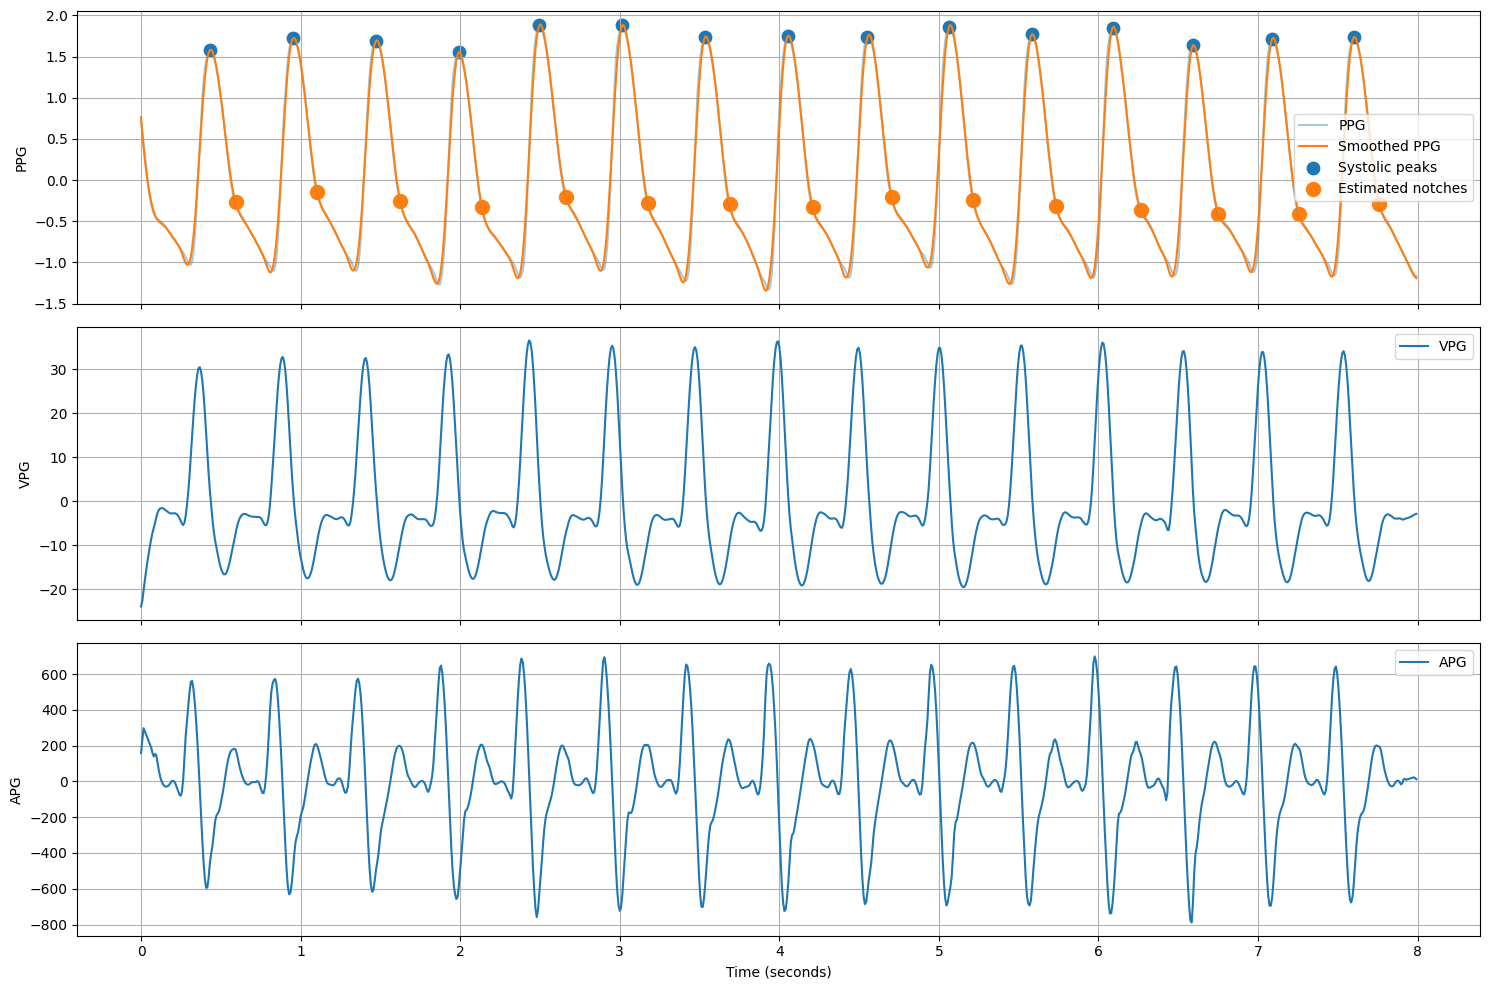

In [13]:
smooth_ppg = savgol_filter(
    ppg_window,
    window_length=21,
    polyorder=3
)
vpg = np.gradient(smooth_ppg) * FS
apg = np.gradient(vpg) * FS


time = np.arange(
    len(ppg_window)
) / FS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True
)


# ==================================================
# PPG
# ==================================================

axes[0].plot(
    time,
    ppg_window,
    alpha=0.4,
    label="PPG"
)

axes[0].plot(
    time,
    smooth_ppg,
    label="Smoothed PPG"
)


# All systolic peaks

axes[0].scatter(
    sys_peaks / FS,
    smooth_ppg[sys_peaks],
    s=80,
    label="Systolic peaks"
)


# All detected notches

valid_notches = [
    n for n in notches
    if n is not None
]

if len(valid_notches) > 0:

    valid_notches = np.array(
        valid_notches,
        dtype=int
    )

    axes[0].scatter(
        valid_notches / FS,
        smooth_ppg[valid_notches],
        s=100,
        label="Estimated notches"
    )


axes[0].set_ylabel("PPG")
axes[0].legend()
axes[0].grid()


# ==================================================
# VPG
# ==================================================

axes[1].plot(
    time,
    vpg,
    label="VPG"
)

axes[1].set_ylabel("VPG")
axes[1].legend()
axes[1].grid()


# ==================================================
# APG
# ==================================================

axes[2].plot(
    time,
    apg,
    label="APG"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("APG")
axes[2].legend()
axes[2].grid()


plt.tight_layout()
plt.show()

In [14]:
delay_time =  get_delay_time(ppg_window)
print(delay_time)

[0.16  0.152 0.152 0.144 0.168 0.16  0.152 0.152 0.152 0.152 0.152 0.176
 0.16  0.168 0.16 ]


In [15]:
X_train, y_train, delay_train, X_val, y_val, delay_val, X_test, y_test, delay_test = prepare_UCI_dataset_w(
    data_path=DATA_PATH, window_size=1000, step_size=1000)

Total recordings: 12000
Train recordings: 8400
Validation recordings: 1200
Test recordings: 2400

Processing TRAIN recordings...


Processing recordings: 100%|██████████| 8400/8400 [06:10<00:00, 22.69it/s]


Skipped recordings: 94

Processing VALIDATION recordings...


Processing recordings: 100%|██████████| 1200/1200 [00:54<00:00, 22.11it/s]


Skipped recordings: 14

Processing TEST recordings...


Processing recordings: 100%|██████████| 2400/2400 [01:50<00:00, 21.79it/s]


Skipped recordings: 16

DATASET SHAPES
X_train: torch.Size([228949, 1, 1000])
y_train: torch.Size([228949, 2])
delay_train: torch.Size([228949])
X_val: torch.Size([33009, 1, 1000])
y_val: torch.Size([33009, 2])
delay_val: torch.Size([33009])
X_test: torch.Size([67313, 1, 1000])
y_test: torch.Size([67313, 2])
delay_test: torch.Size([67313])


In [16]:
print("Shape:", delay_train.shape)
print("Dtype:", delay_train.dtype)
print("NaN count:", np.isnan(delay_train).sum())
delay_train_np = delay_train.detach().cpu().numpy().astype(np.float32)
print(
    "NaN percentage:",
    100 * np.isnan(delay_train_np).mean(),
    "%"
)

valid_delay = delay_train_np[
    np.isfinite(delay_train_np)
]

print("Valid values:", len(valid_delay))

if len(valid_delay) > 0:

    print("\nStatistics:")

    print(
        "Min    :",
        np.min(valid_delay)
    )

    print(
        "Max    :",
        np.max(valid_delay)
    )

    print(
        "Mean   :",
        np.mean(valid_delay)
    )

    print(
        "Median :",
        np.median(valid_delay)
    )

    print(
        "Std    :",
        np.std(valid_delay)
    )

if len(valid_delay) > 0:

    print("\nRange checks:")

    print(
        "Below 0.08 s:",
        np.sum(valid_delay < 0.08)
    )

    print(
        "Above 0.35 s:",
        np.sum(valid_delay > 0.35)
    )

    print(
        "Within 0.08–0.35 s:",
        np.sum(
            (valid_delay >= 0.08) &
            (valid_delay <= 0.35)
        )
    )


if len(valid_delay) > 0:

    print("\nPercentiles:")

    for p in [1, 5, 25, 50, 75, 95, 99]:

        print(
            f"{p:2d}% :",
            np.percentile(valid_delay, p)
        )

Shape: torch.Size([228949])
Dtype: torch.float32
NaN count: tensor(0)
NaN percentage: 0.0 %
Valid values: 228949

Statistics:
Min    : 0.088
Max    : 0.336
Mean   : 0.18097515
Median : 0.176
Std    : 0.036773372

Range checks:
Below 0.08 s: 0
Above 0.35 s: 0
Within 0.08–0.35 s: 228949

Percentiles:
 1% : 0.112
 5% : 0.128
25% : 0.152
50% : 0.176
75% : 0.208
95% : 0.24399999
99% : 0.28


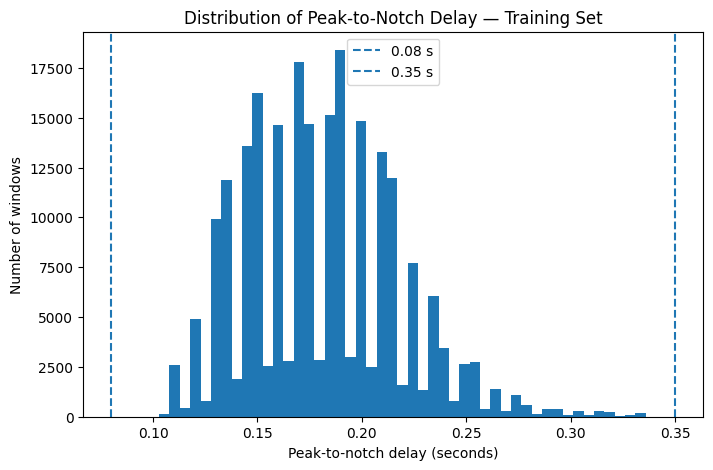

In [17]:
import matplotlib.pyplot as plt

valid_delay = delay_train[
    np.isfinite(delay_train)
]

plt.figure(figsize=(8, 5))

plt.hist(
    valid_delay,
    bins=50
)

plt.xlabel("Peak-to-notch delay (seconds)")
plt.ylabel("Number of windows")
plt.title("Distribution of Peak-to-Notch Delay — Training Set")

plt.axvline(
    0.08,
    linestyle="--",
    label="0.08 s"
)

plt.axvline(
    0.35,
    linestyle="--",
    label="0.35 s"
)

plt.legend()

plt.show()

In [18]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("delay_train:", delay_train.shape)

print(
    "Number of windows:",
    len(X_train)
)

print(
    "Number of BP labels:",
    len(y_train)
)

print(
    "Number of delays:",
    len(delay_train)
)

X_train: torch.Size([228949, 1, 1000])
y_train: torch.Size([228949, 2])
delay_train: torch.Size([228949])
Number of windows: 228949
Number of BP labels: 228949
Number of delays: 228949


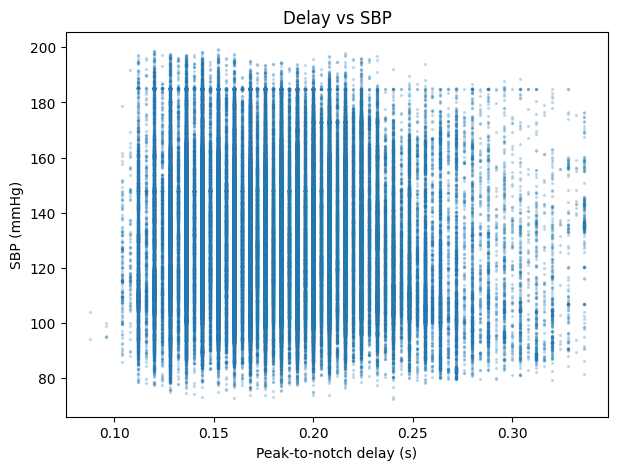

In [19]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 0],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("SBP (mmHg)")
plt.title("Delay vs SBP")

plt.show()

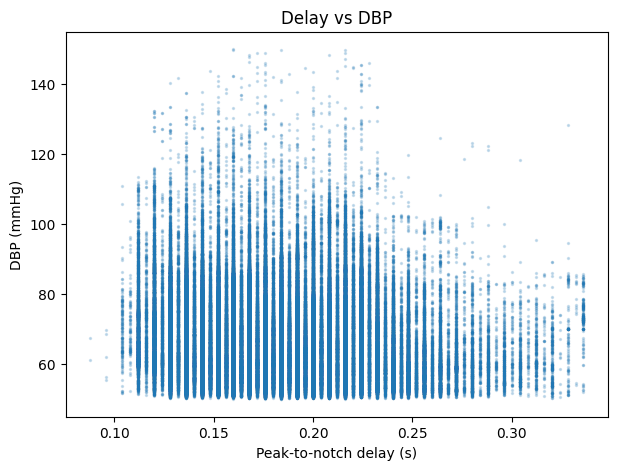

In [20]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 1],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("DBP (mmHg)")
plt.title("Delay vs DBP")

plt.show()

## RC Estimation ##

In [21]:
RC, RC_values = estimate_RC(
    sbp=y_train[:, 0].numpy(),
    dbp=y_train[:, 1].numpy(),
    delay=delay_train
)

Total windows: 228949
Valid windows: 228949
Valid percentage: 100.0 %

Windkessel RC Estimation
Median RC : 0.2677 s
Mean RC   : 0.2897 s
Std RC    : 0.1107 s
Min RC    : 0.1104 s
Max RC    : 1.4953 s


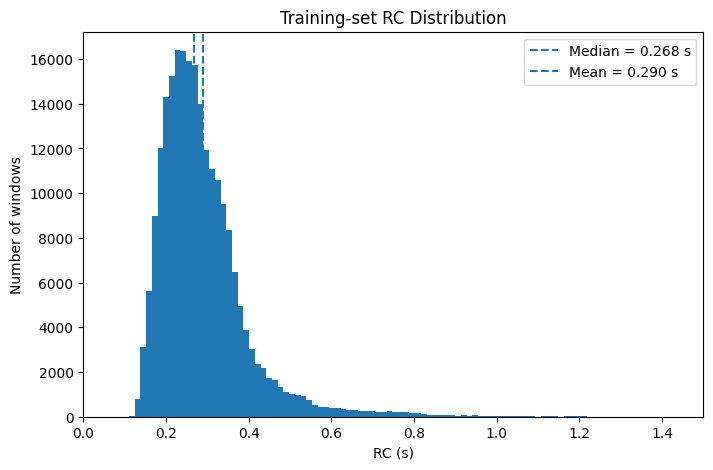

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(
    RC_values,
    bins=100
)

plt.axvline(
    np.median(RC_values),
    linestyle="--",
    label=f"Median = {np.median(RC_values):.3f} s"
)
plt.axvline(
    np.mean(RC_values),
    linestyle="--",
    label=f"Mean = {np.mean(RC_values):.3f} s"
)

plt.xlabel("RC (s)")
plt.xlim(0,1.5)
plt.ylabel("Number of windows")
plt.title("Training-set RC Distribution")
plt.legend()

plt.show()

It's a highly skewed distribution, so using mean won't be a good idea

In [23]:
for p in [1, 5, 25, 50, 75, 90, 95, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}% : "
        f"{np.percentile(RC_values, p):.4f} s"
    )

  1.0% : 0.1461 s
  5.0% : 0.1692 s
 25.0% : 0.2187 s
 50.0% : 0.2677 s
 75.0% : 0.3316 s
 90.0% : 0.4046 s
 95.0% : 0.4839 s
 99.0% : 0.7411 s
 99.5% : 0.8228 s
 99.9% : 1.0450 s


In [24]:
RC = 0.2994

sbp = y_train[:, 0].cpu().numpy()
dbp = y_train[:, 1].cpu().numpy()
delay = delay_train.cpu().numpy()

dbp_physics = (
    sbp *
    np.exp(-delay / RC)
)

physics_mae = np.mean(
    np.abs(dbp_physics - dbp)
)

physics_rmse = np.sqrt(
    np.mean(
        (dbp_physics - dbp) ** 2
    )
)

print("Physics-only DBP MAE :", physics_mae)
print("Physics-only DBP RMSE:", physics_rmse)

Physics-only DBP MAE : 11.569307
Physics-only DBP RMSE: 14.774671


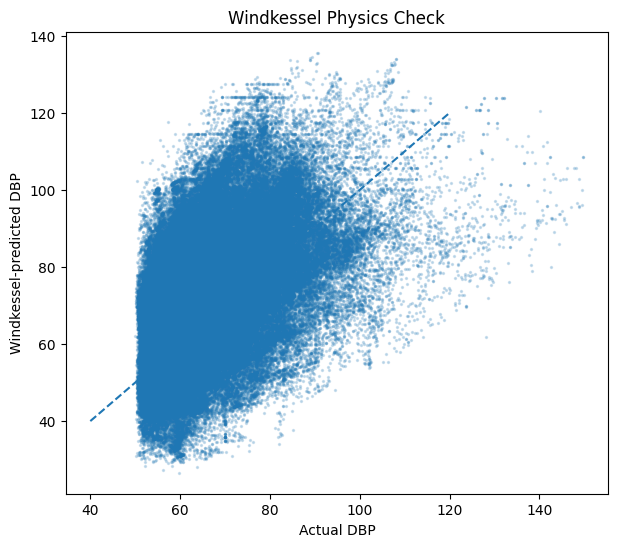

In [25]:
plt.figure(figsize=(7, 6))

plt.scatter(
    dbp,
    dbp_physics,
    s=2,
    alpha=0.2
)

plt.plot(
    [40, 120],
    [40, 120],
    linestyle="--"
)

plt.xlabel("Actual DBP")
plt.ylabel("Windkessel-predicted DBP")
plt.title("Windkessel Physics Check")

plt.show()

In [26]:
rc_values, mae_values, rmse_values, best_RC_MAE, best_RC_RMSE = grid_search_RC(
    sbp=y_train[:, 0].cpu().numpy(),
    dbp=y_train[:, 1].cpu().numpy(),
    delay=delay_train.cpu().numpy(),
    rc_min=0.10,
    rc_max=1.00,
    rc_step=0.005
)
RC = best_RC_MAE

Valid samples: 228949

RC GRID SEARCH RESULTS
Best RC by MAE  : 0.2650 s
Best MAE        : 10.7658 mmHg

Best RC by RMSE : 0.2650 s
Best RMSE       : 13.6675 mmHg


## Establishing Baseline using 1D ResNet ##

In [27]:
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [28]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([228949, 1, 1000])
y_train: torch.Size([228949, 2])
X_val: torch.Size([33009, 1, 1000])
y_val: torch.Size([33009, 2])
X_test: torch.Size([67313, 1, 1000])
y_test: torch.Size([67313, 2])


In [29]:
train_loader, val_loader, test_loader = create_data_loaders(
    X_train, y_train,
    X_val, y_val,  
    X_test, y_test)


Epoch [01/50] LR: 1.00e-04 | Train MSE: 7718.2574 | Train SBP MSE: 12728.2734 | Train DBP MSE: 2708.2415 | Train SBP RMSE: 112.8196 | Train DBP RMSE: 52.0408 | Val MSE: 5028.9789 | Val SBP MSE: 8881.1861 | Val DBP MSE: 1176.7717 | Val SBP RMSE: 94.2400 | Val DBP RMSE: 34.3041
Epoch [02/50] LR: 1.00e-04 | Train MSE: 2910.4280 | Train SBP MSE: 5372.9194 | Train DBP MSE: 447.9366 | Train SBP RMSE: 73.3002 | Train DBP RMSE: 21.1645 | Val MSE: 1705.6225 | Val SBP MSE: 3249.9732 | Val DBP MSE: 161.2719 | Val SBP RMSE: 57.0085 | Val DBP RMSE: 12.6993
Epoch [03/50] LR: 1.00e-04 | Train MSE: 712.0739 | Train SBP MSE: 1316.8998 | Train DBP MSE: 107.2480 | Train SBP RMSE: 36.2891 | Train DBP RMSE: 10.3561 | Val MSE: 280.7544 | Val SBP MSE: 447.4594 | Val DBP MSE: 114.0494 | Val SBP RMSE: 21.1532 | Val DBP RMSE: 10.6794
Epoch [04/50] LR: 1.00e-04 | Train MSE: 242.5404 | Train SBP MSE: 382.5783 | Train DBP MSE: 102.5024 | Train SBP RMSE: 19.5596 | Train DBP RMSE: 10.1243 | Val MSE: 226.9161 | Val S

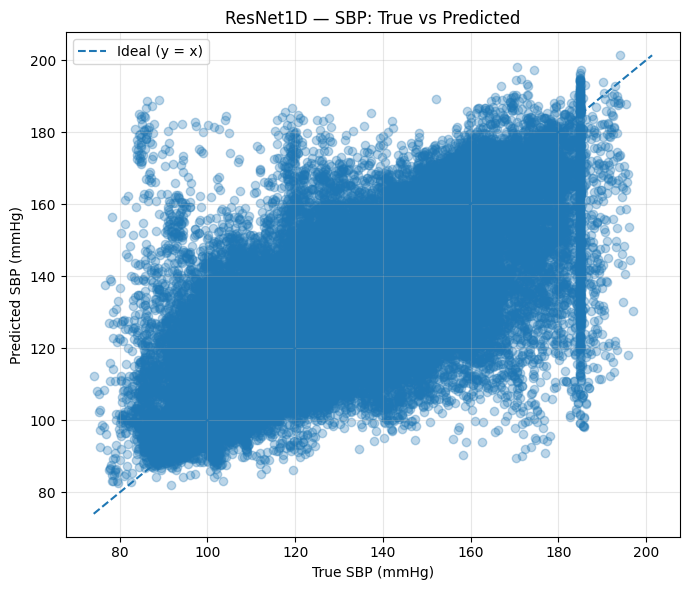

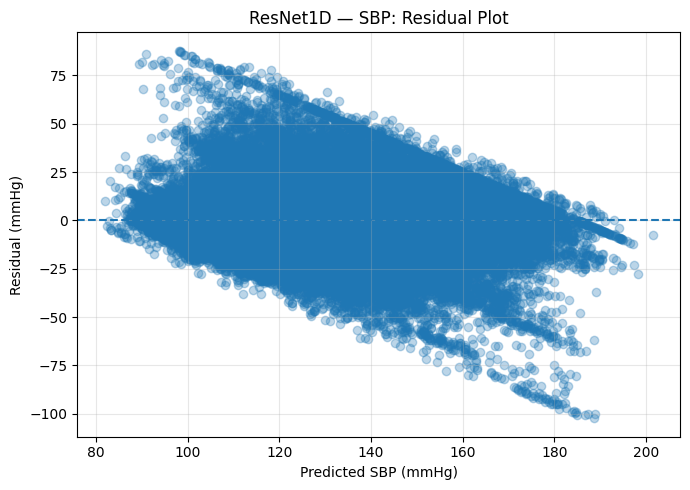

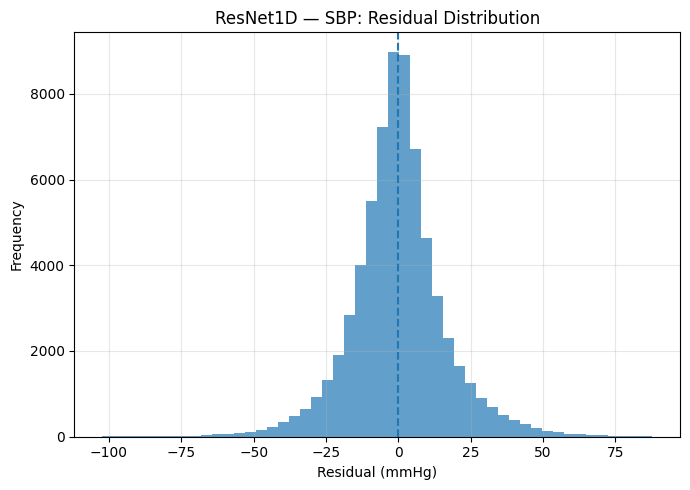

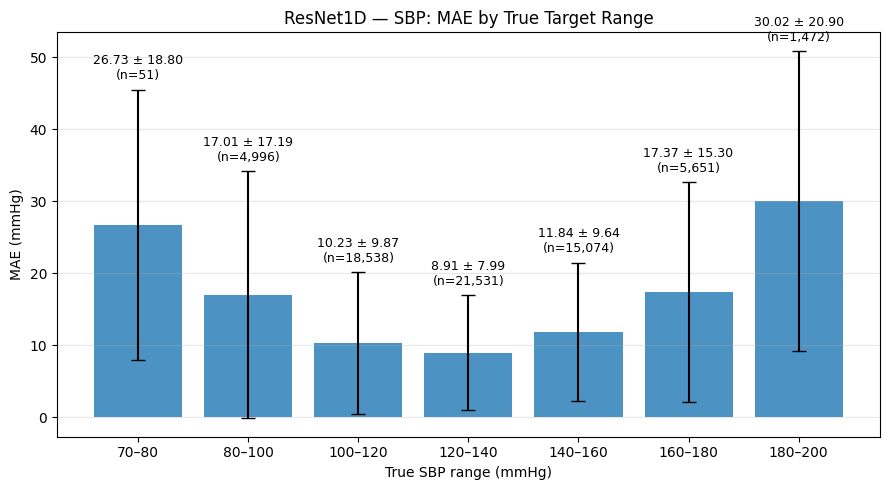



DBP TEST RESULTS
RMSE: 8.8463
MSE : 78.2570
R²  : 0.3691
MAE : 5.9937


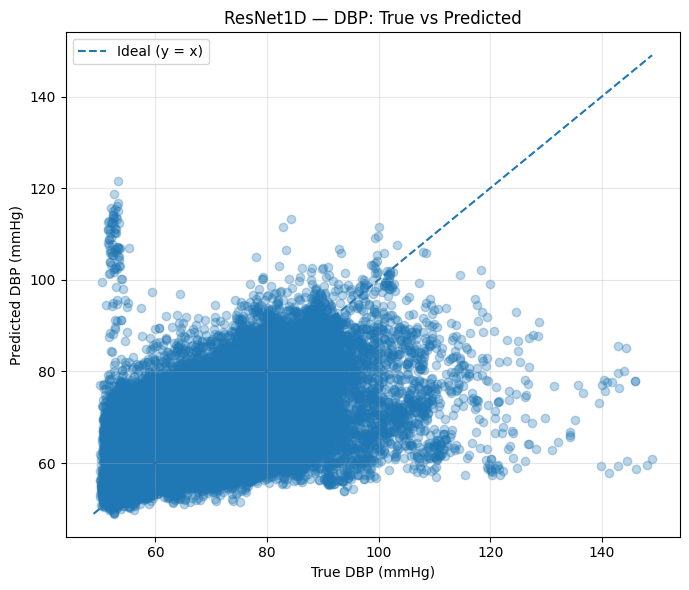

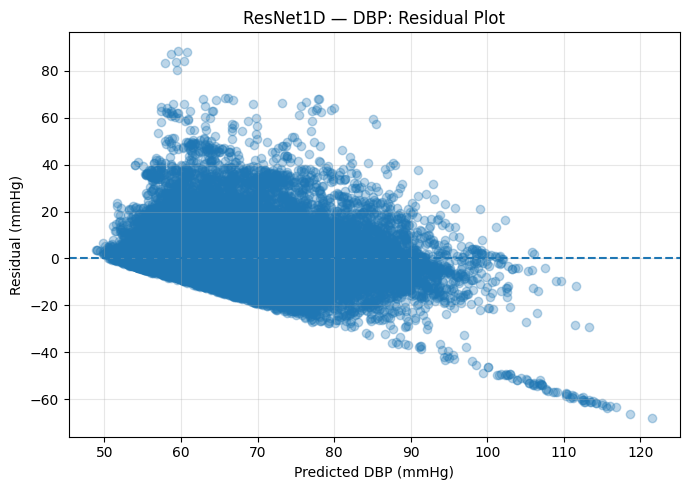

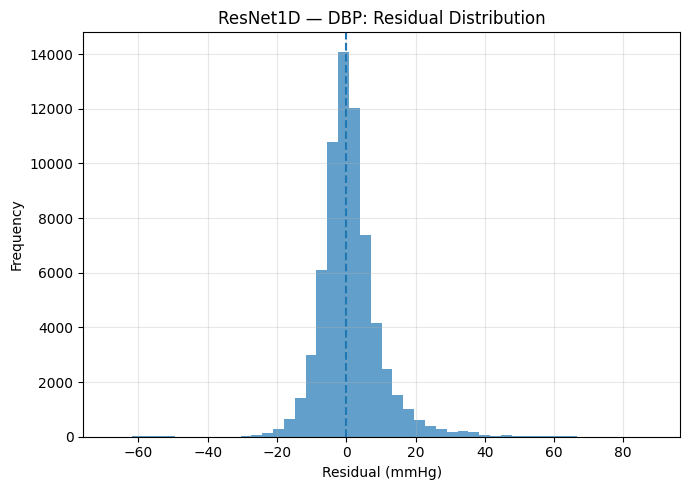

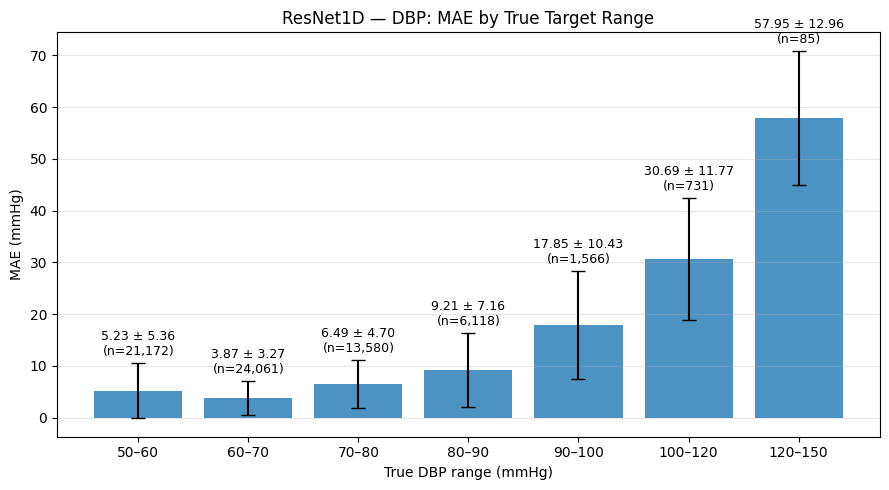

In [30]:
model, history, y_true, y_pred = train_resnet1d(
    train_loader,
    val_loader,
    test_loader,
    device,
    epochs=50
)

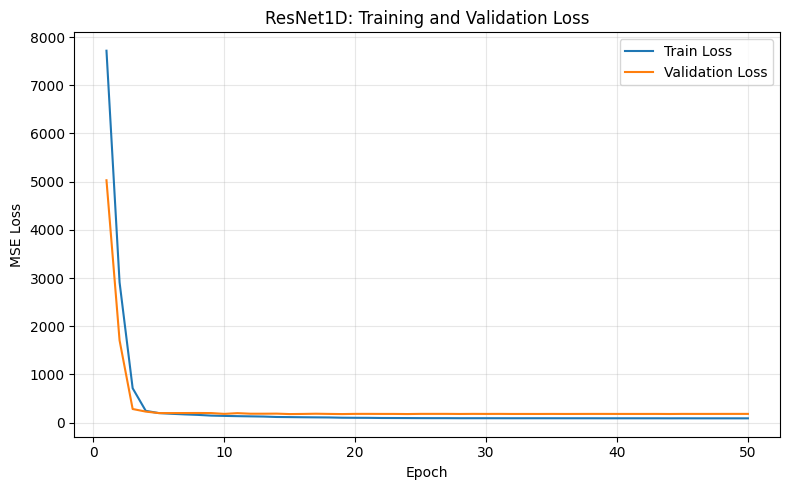

In [31]:
plot_training_loss(
    history,
    model_name="ResNet1D"
)

## Physics Informed Windkessel ##

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15463.3730 | Train SBP MSE: 12798.0435 | Train DBP MSE: 2665.3209 | Train Phys: 86.1626 | Train RMSE: SBP=113.128, DBP=51.627 | Val Total: 10780.8027 | Val SBP MSE: 9541.5257 | Val DBP MSE: 1239.2546 | Val Phys: 223.9109 | Val RMSE: SBP=97.681, DBP=35.203 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 5067.5336 | Train SBP MSE: 4742.3596 | Train DBP MSE: 325.1279 | Train Phys: 460.8219 | Train RMSE: SBP=68.865, DBP=18.031 | Val Total: 2157.4155 | Val SBP MSE: 2057.5353 | Val DBP MSE: 99.8435 | Val Phys: 366.3372 | Val RMSE: SBP=45.360, DBP=9.992 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 913.3715 | Train SBP MSE: 809.5613 | Train DBP MSE: 103.7906 | Train Phys: 196.6795 | Train RMSE: SBP=28.453, DBP=10.188 | Val Total: 457.1227 | Val SBP MSE: 334.0356 | Val DBP MSE: 123.0780 | Val Phys: 90.6955 | Val RMSE: SBP=18.277, DBP=11.094 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 420.5982 | Train SBP MSE: 321.8378 | Train DBP MSE: 98.75

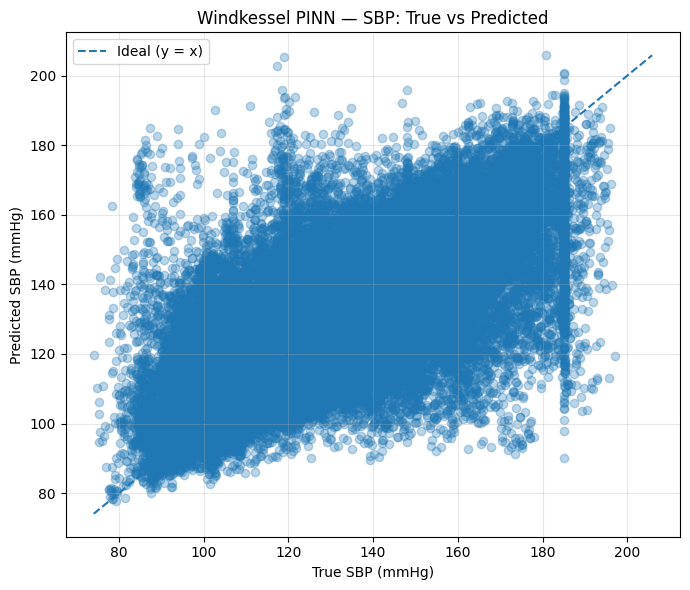

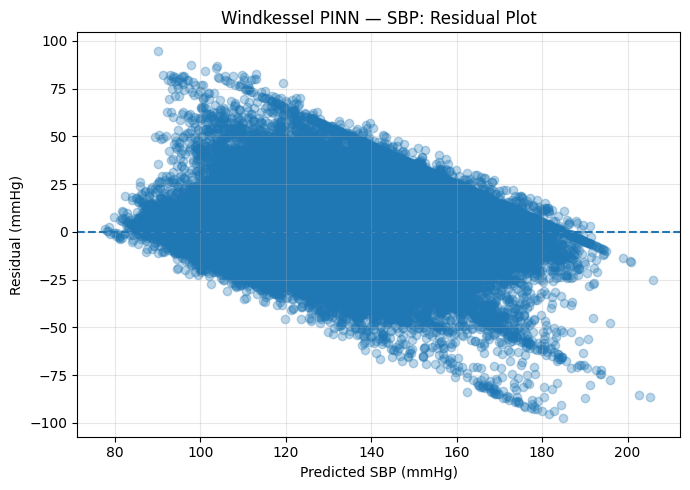

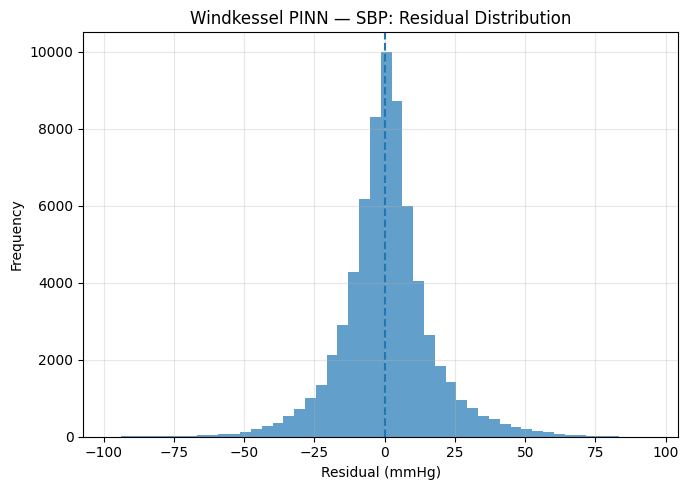

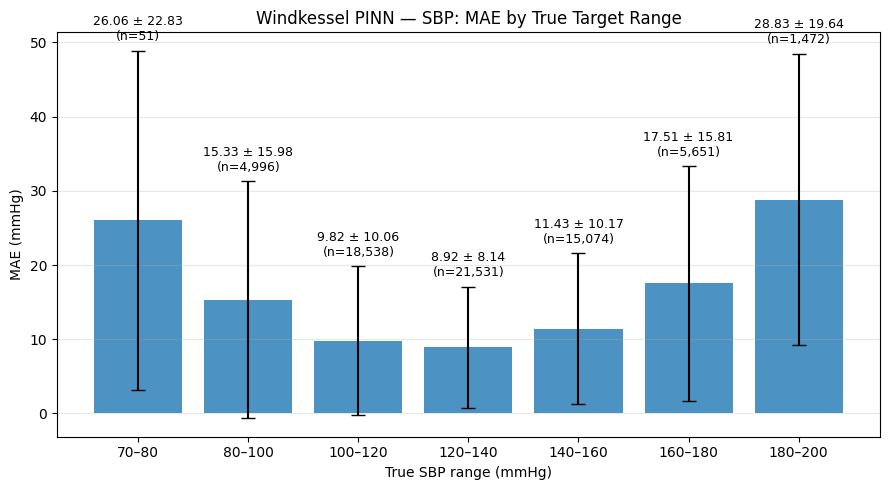


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.7115
MSE : 75.8895
R²  : 0.3881
MAE : 5.8950


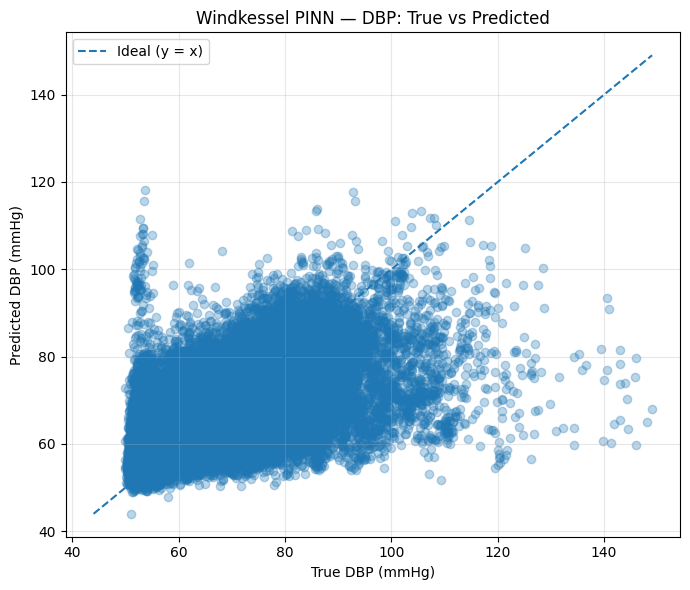

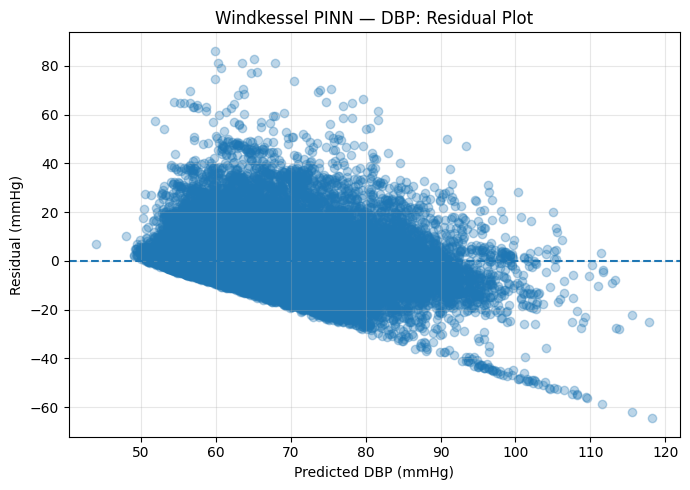

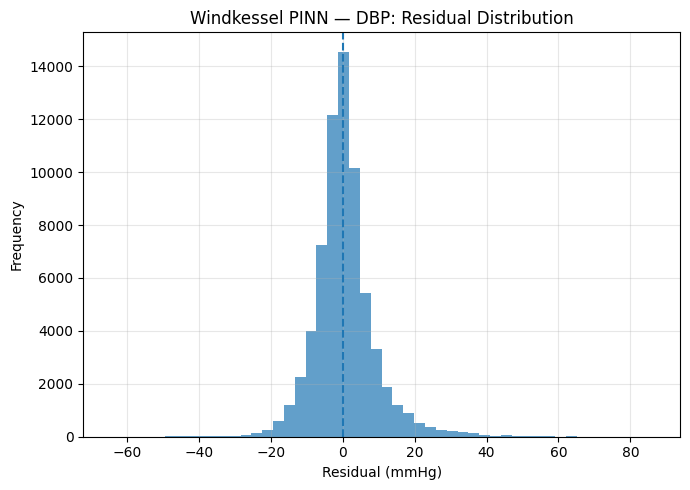

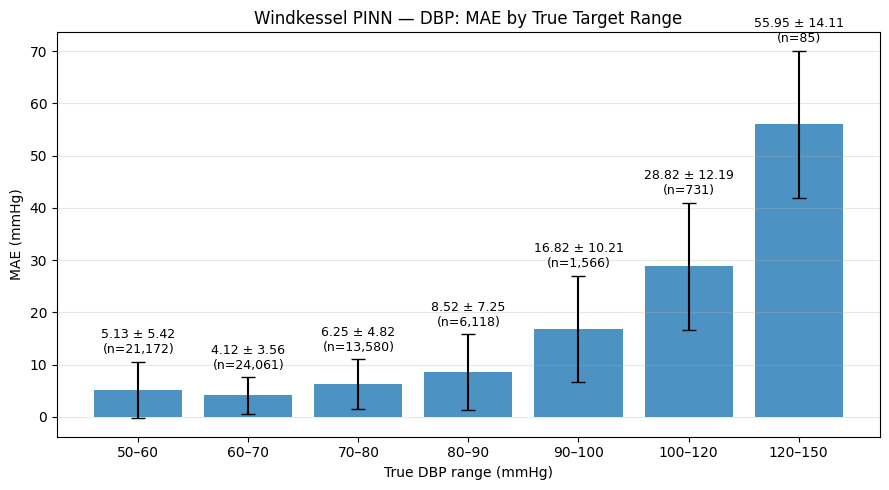

In [32]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.0001
)

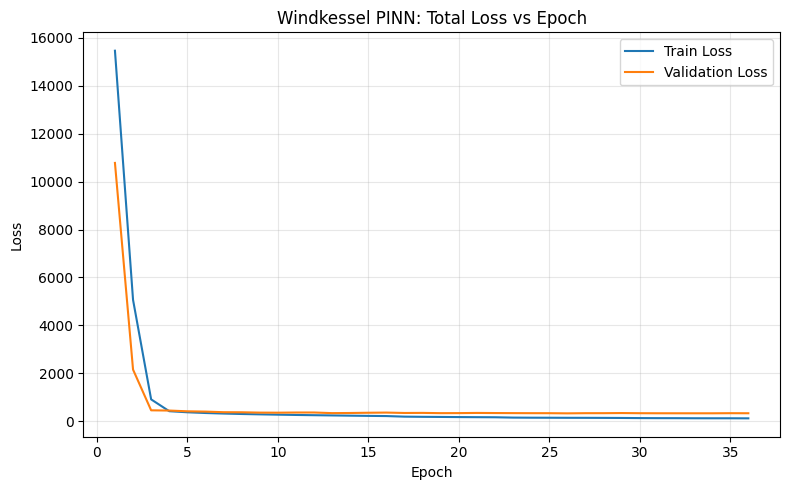

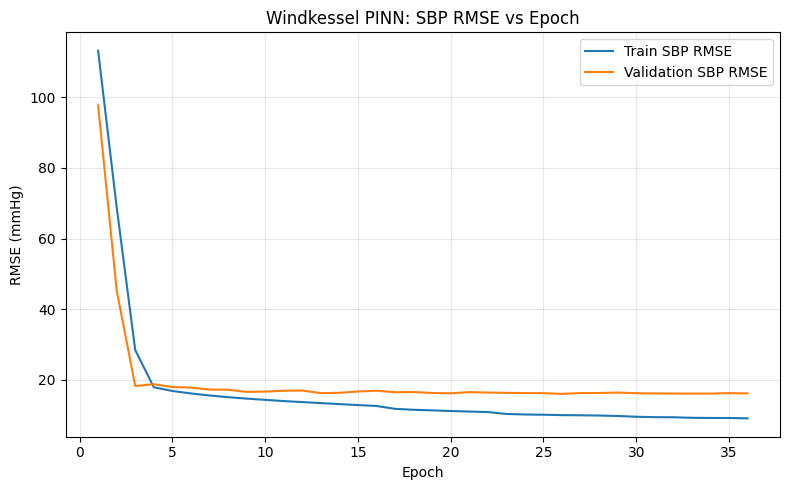

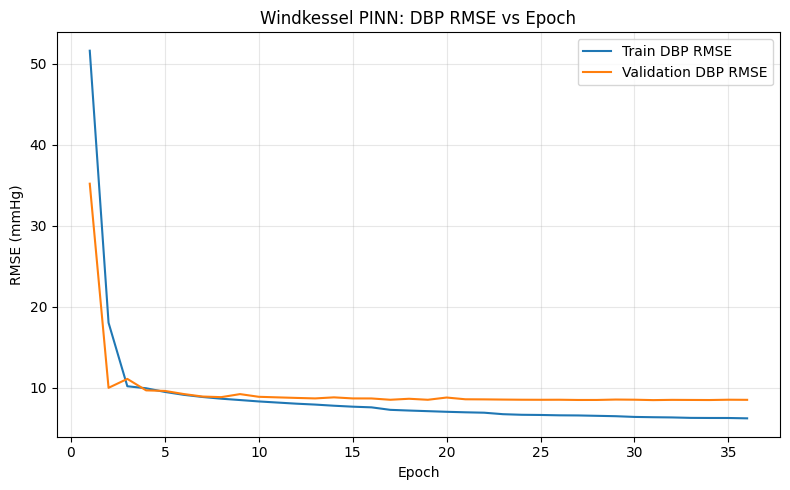

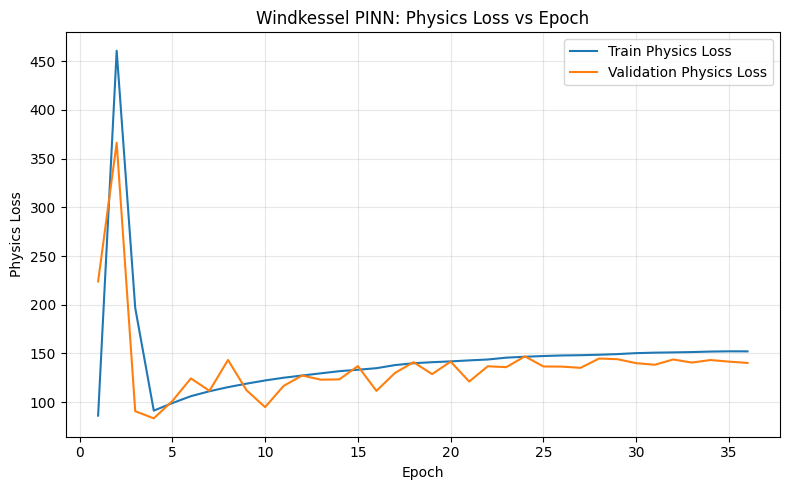

In [33]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16301.3779 | Train SBP MSE: 13330.9436 | Train DBP MSE: 2970.3834 | Train Phys: 50.9701 | Train RMSE: SBP=115.460, DBP=54.501 | Val Total: 10094.9648 | Val SBP MSE: 8867.0085 | Val DBP MSE: 1227.7636 | Val Phys: 192.7007 | Val RMSE: SBP=94.165, DBP=35.039 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6499.8077 | Train SBP MSE: 5927.5320 | Train DBP MSE: 571.9002 | Train Phys: 375.5056 | Train RMSE: SBP=76.990, DBP=23.914 | Val Total: 2444.6837 | Val SBP MSE: 2328.0476 | Val DBP MSE: 116.1533 | Val Phys: 482.7061 | Val RMSE: SBP=48.250, DBP=10.777 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1320.2215 | Train SBP MSE: 1202.9892 | Train DBP MSE: 116.9571 | Train Phys: 275.2378 | Train RMSE: SBP=34.684, DBP=10.815 | Val Total: 555.7838 | Val SBP MSE: 457.1152 | Val DBP MSE: 98.5646 | Val Phys: 104.0355 | Val RMSE: SBP=21.380, DBP=9.928 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 476.6105 | Train SBP MSE: 367.5853 | Train DBP MSE: 10

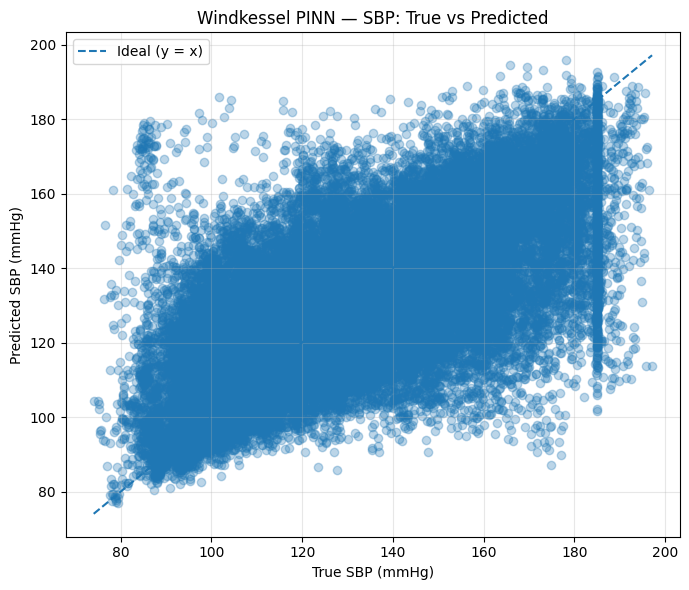

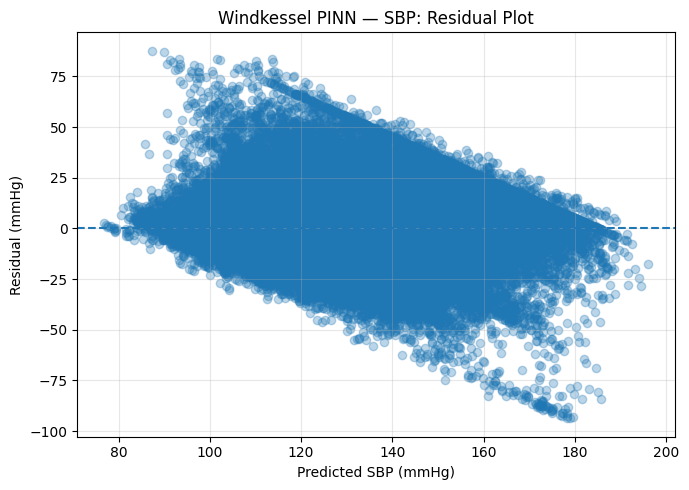

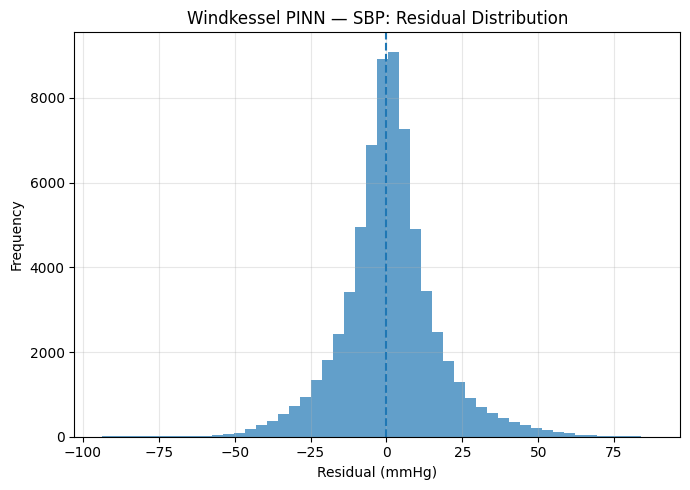

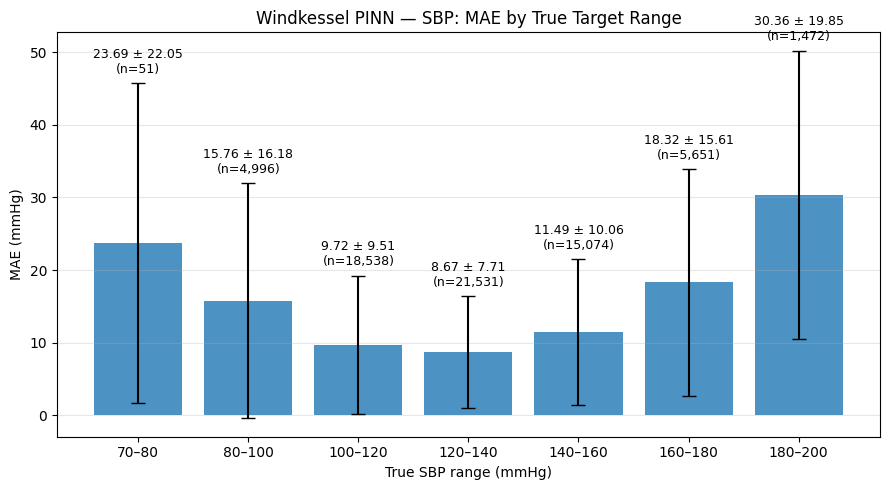


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.5801
MSE : 73.6185
R²  : 0.4064
MAE : 5.8014


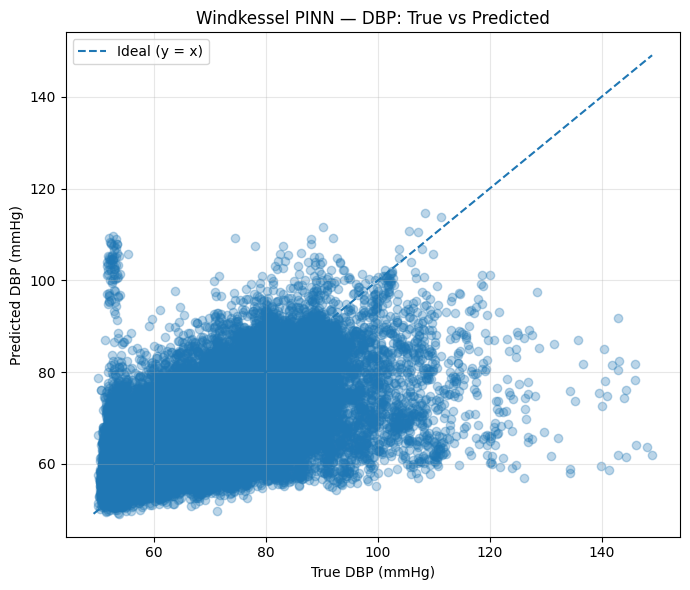

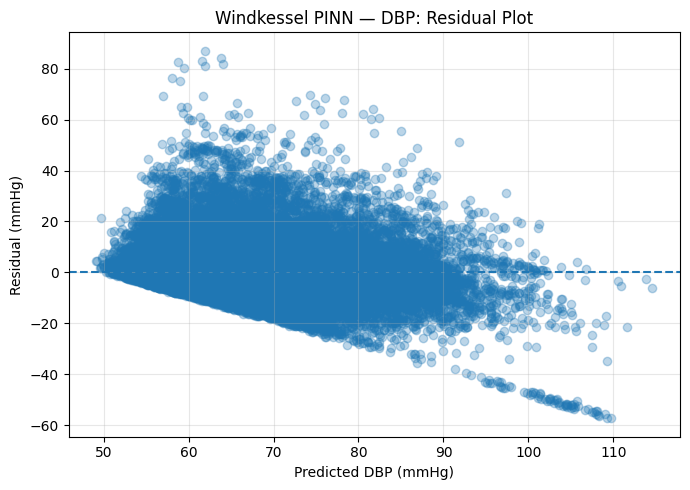

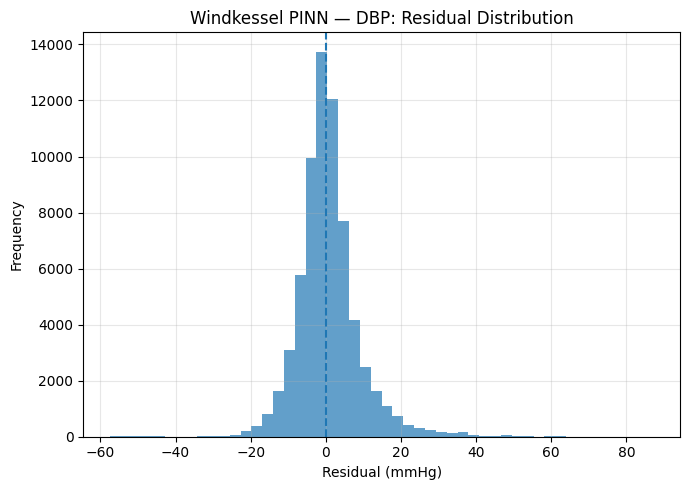

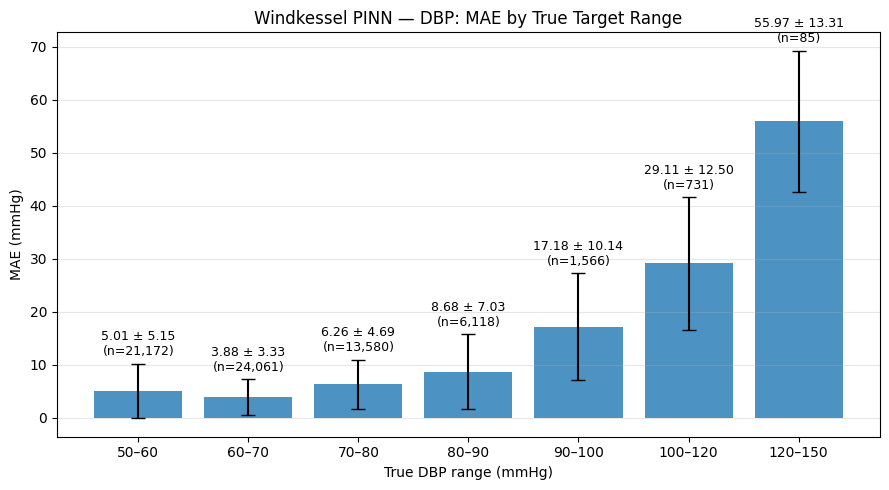

In [34]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.001
)

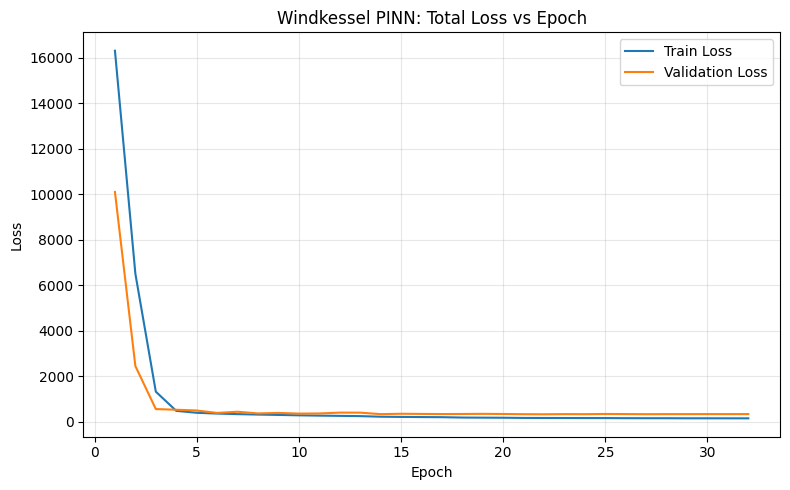

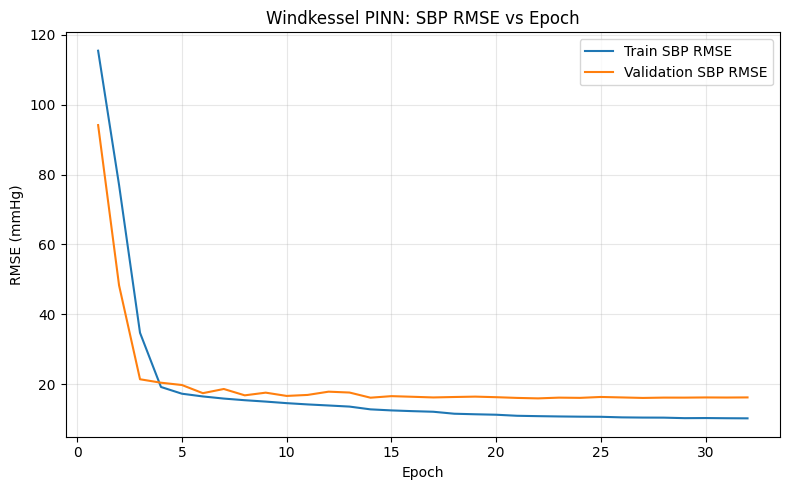

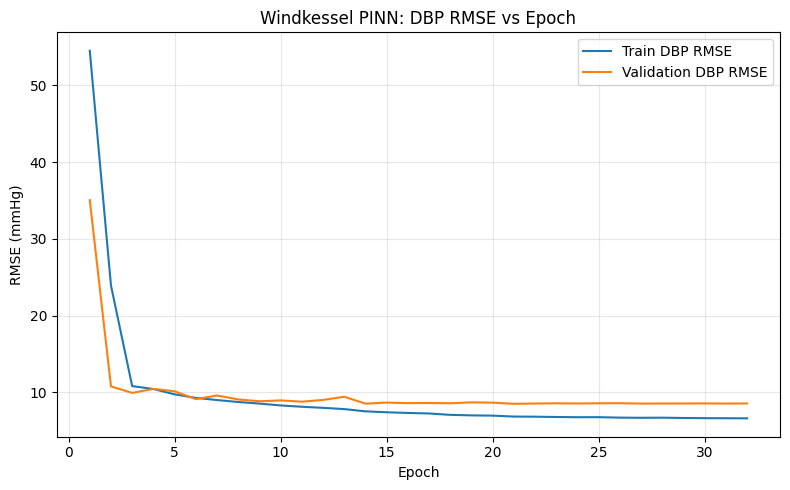

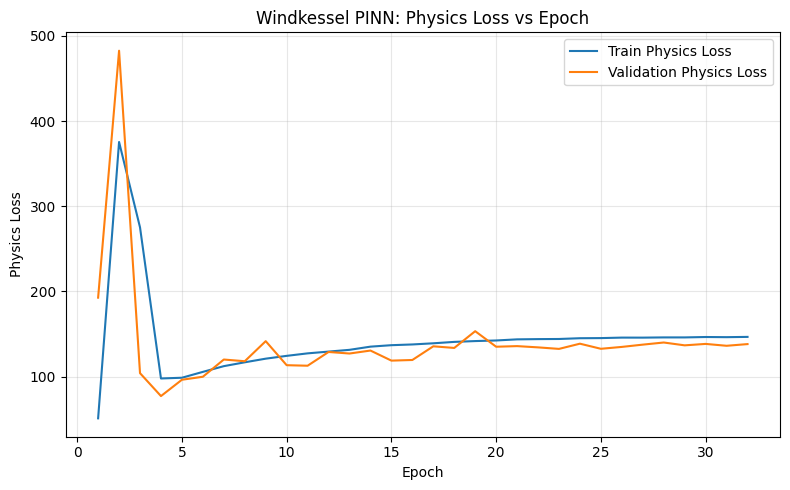

In [35]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15541.3396 | Train SBP MSE: 12662.2015 | Train DBP MSE: 2878.7483 | Train Phys: 38.9855 | Train RMSE: SBP=112.526, DBP=53.654 | Val Total: 10507.5387 | Val SBP MSE: 9089.4921 | Val DBP MSE: 1416.7508 | Val Phys: 129.5887 | Val RMSE: SBP=95.339, DBP=37.640 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 5978.5769 | Train SBP MSE: 5425.7573 | Train DBP MSE: 549.7307 | Train Phys: 308.8955 | Train RMSE: SBP=73.660, DBP=23.446 | Val Total: 2905.4154 | Val SBP MSE: 2763.7666 | Val DBP MSE: 138.1059 | Val Phys: 354.2800 | Val RMSE: SBP=52.572, DBP=11.752 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1243.6139 | Train SBP MSE: 1133.6298 | Train DBP MSE: 107.5481 | Train Phys: 243.5988 | Train RMSE: SBP=33.669, DBP=10.371 | Val Total: 472.2097 | Val SBP MSE: 363.5391 | Val DBP MSE: 107.6860 | Val Phys: 98.4646 | Val RMSE: SBP=19.067, DBP=10.377 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 440.3674 | Train SBP MSE: 338.2946 | Train DBP MSE: 1

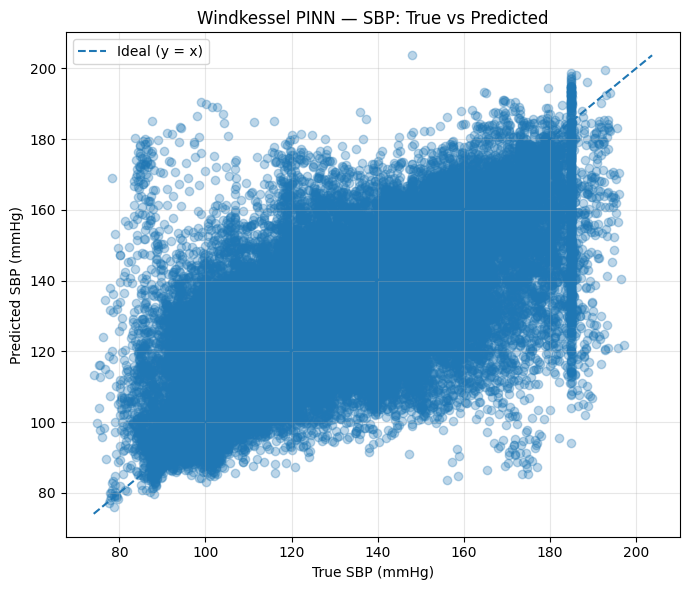

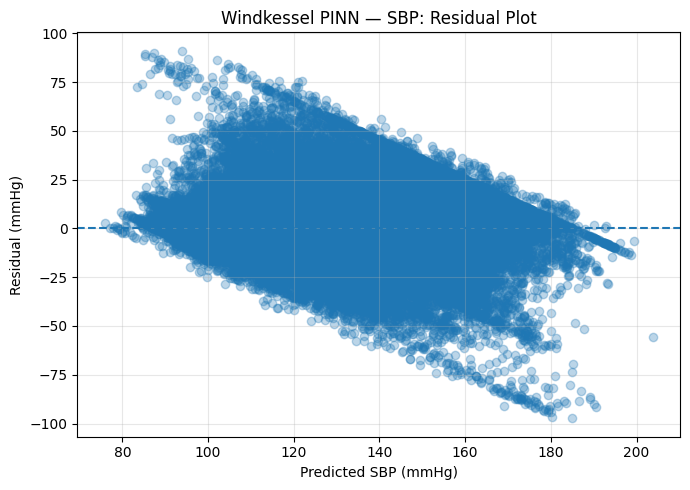

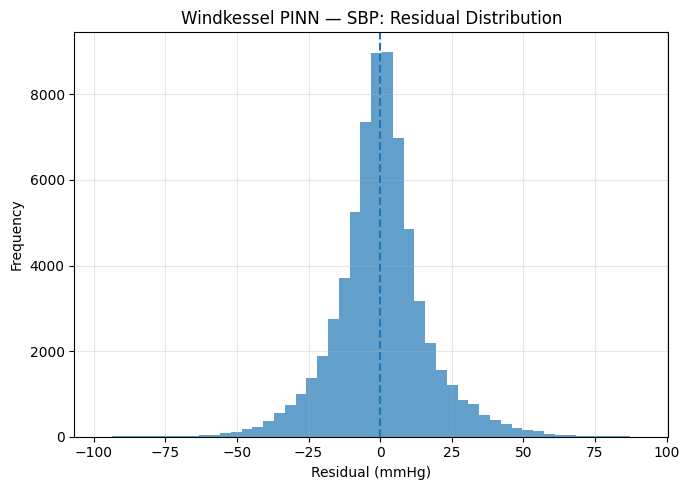

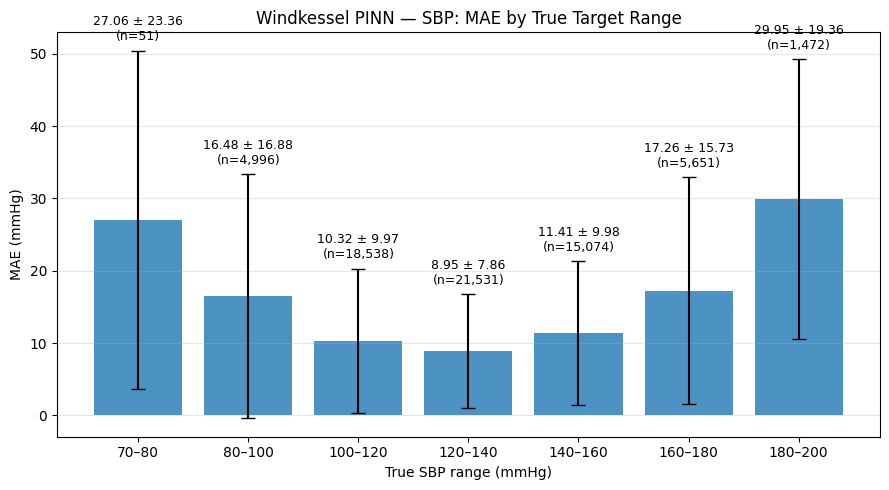


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.6411
MSE : 74.6680
R²  : 0.3980
MAE : 5.8834


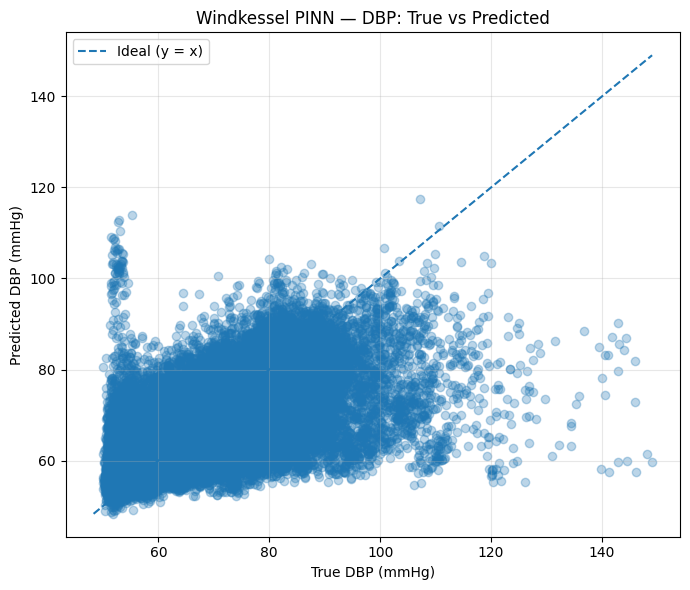

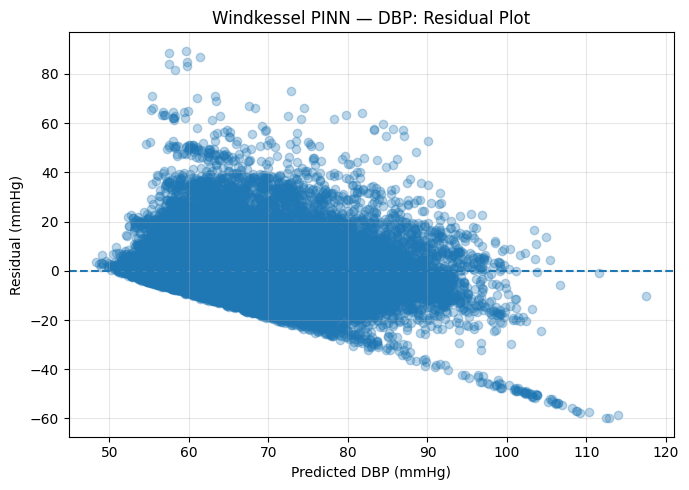

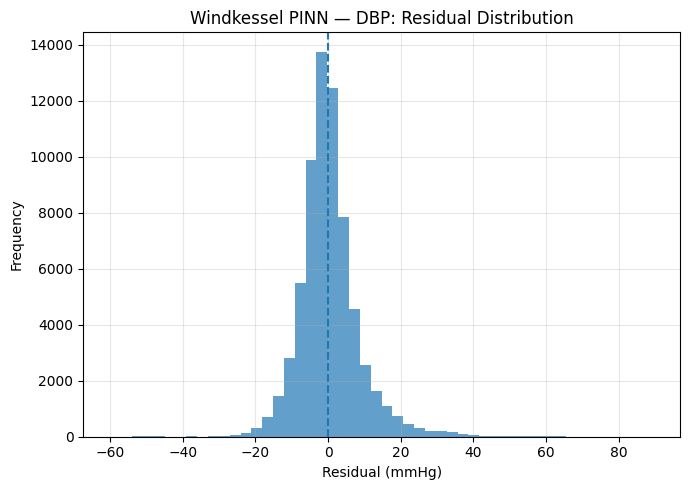

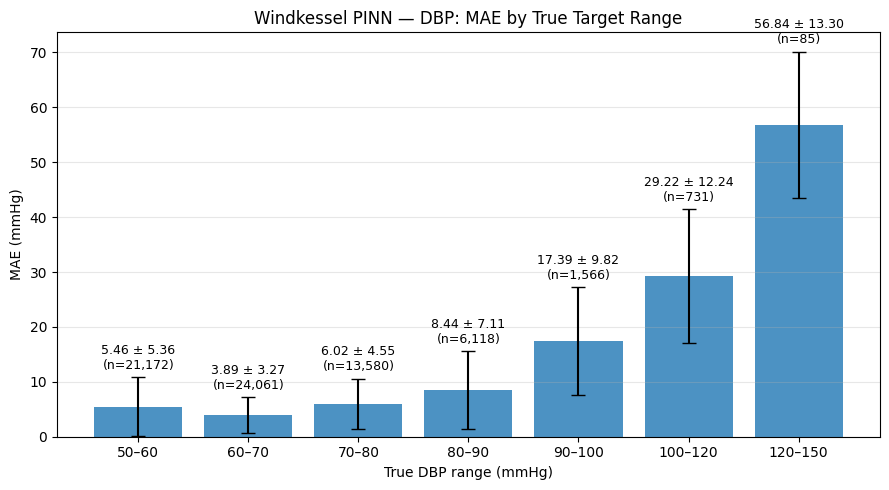

In [36]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.01
)

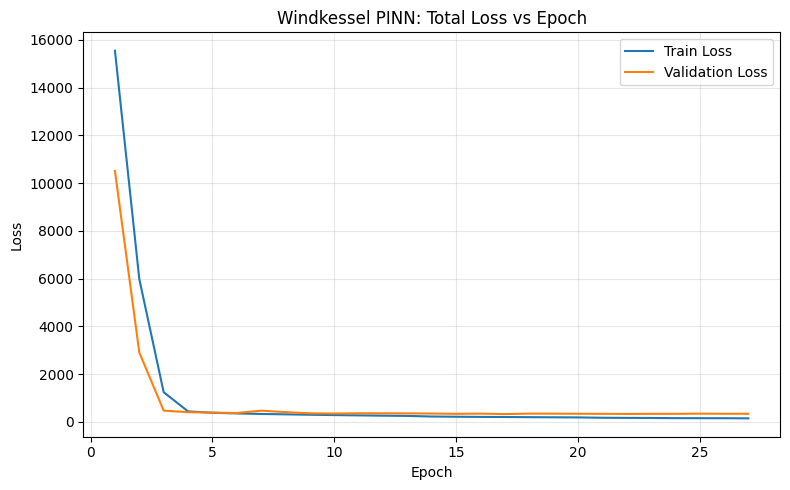

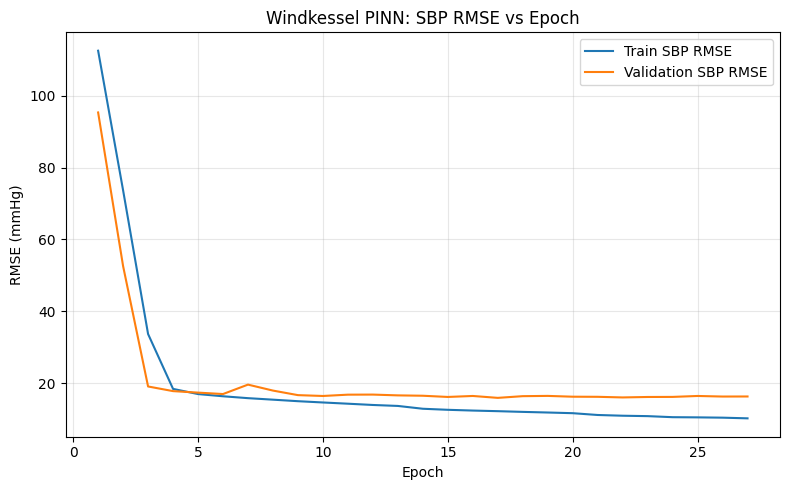

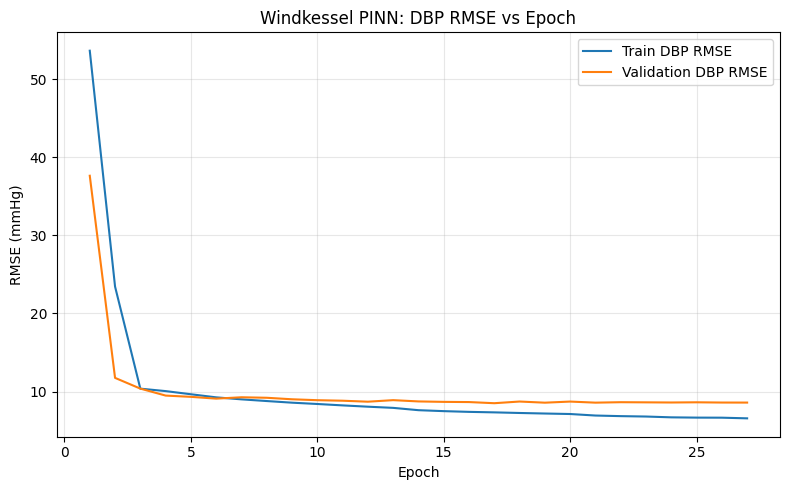

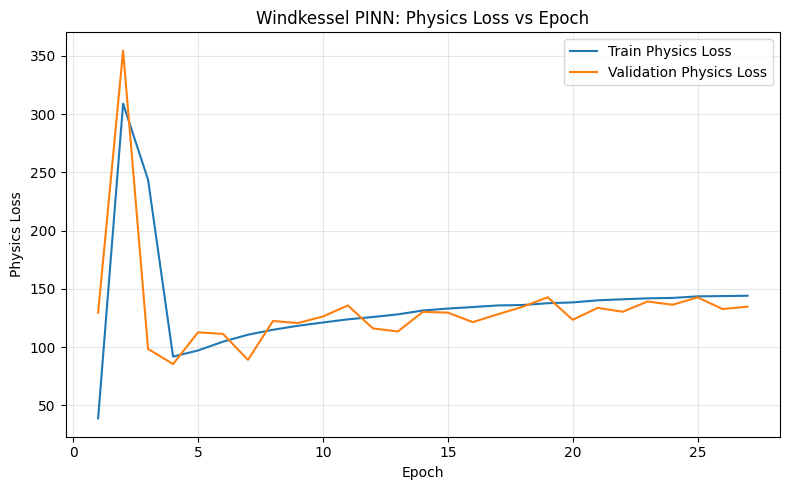

In [37]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15588.1805 | Train SBP MSE: 12770.9093 | Train DBP MSE: 2812.2076 | Train Phys: 50.6358 | Train RMSE: SBP=113.008, DBP=53.030 | Val Total: 10720.4843 | Val SBP MSE: 9331.1574 | Val DBP MSE: 1372.3640 | Val Phys: 169.6293 | Val RMSE: SBP=96.598, DBP=37.045 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6008.4308 | Train SBP MSE: 5467.1685 | Train DBP MSE: 506.5139 | Train Phys: 347.4839 | Train RMSE: SBP=73.940, DBP=22.506 | Val Total: 2908.3912 | Val SBP MSE: 2730.0285 | Val DBP MSE: 144.2345 | Val Phys: 341.2810 | Val RMSE: SBP=52.250, DBP=12.010 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1210.6160 | Train SBP MSE: 1081.3930 | Train DBP MSE: 107.9956 | Train Phys: 212.2737 | Train RMSE: SBP=32.885, DBP=10.392 | Val Total: 579.5050 | Val SBP MSE: 474.0529 | Val DBP MSE: 97.0401 | Val Phys: 84.1196 | Val RMSE: SBP=21.773, DBP=9.851 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 445.9661 | Train SBP MSE: 335.5207 | Train DBP MSE: 101

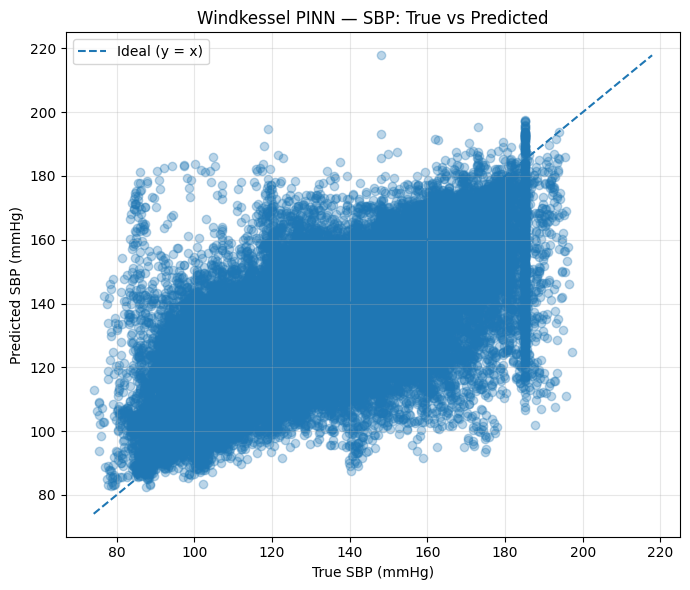

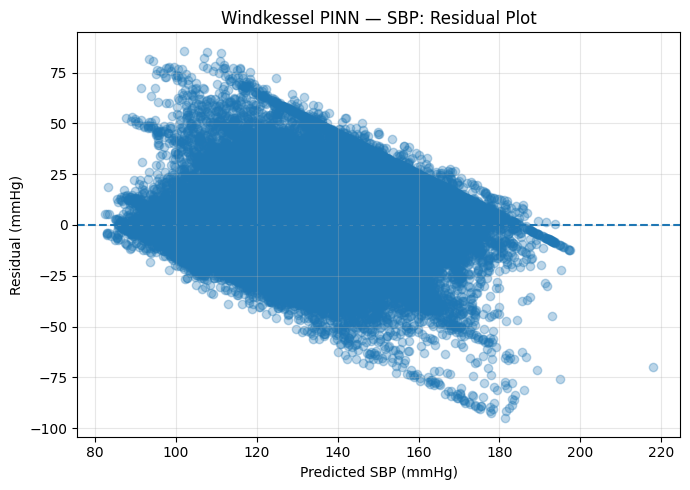

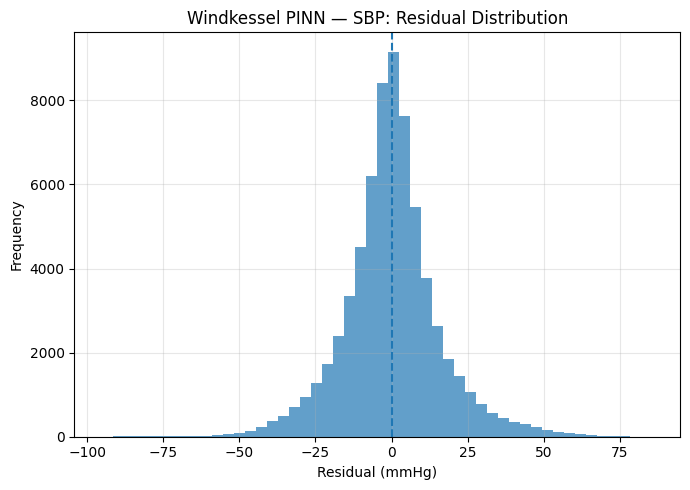

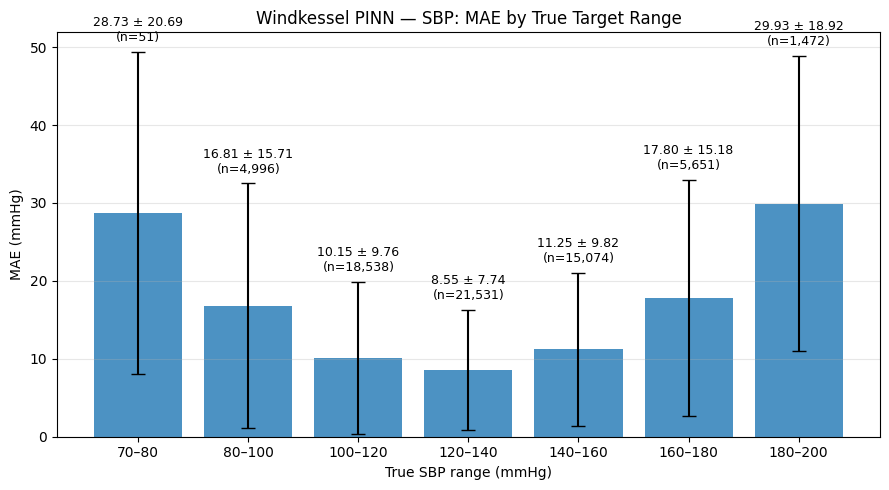


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 8.6537
MSE : 74.8858
R²  : 0.3962
MAE : 5.9590


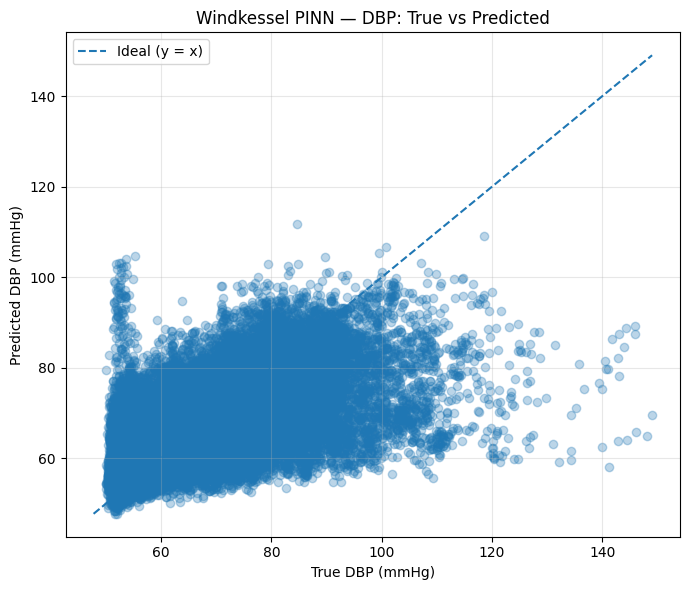

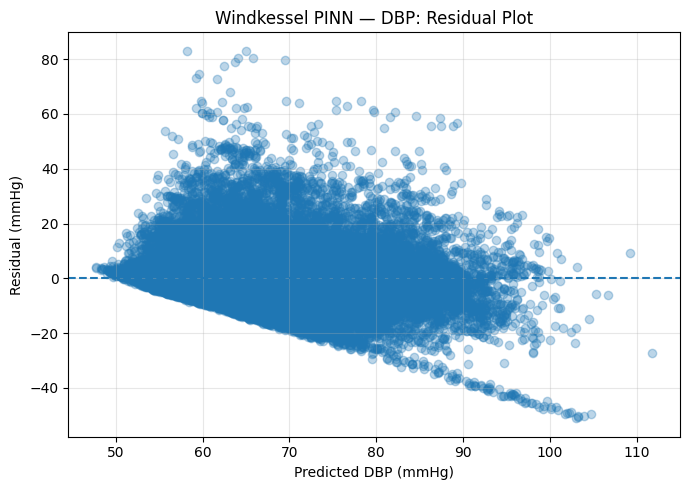

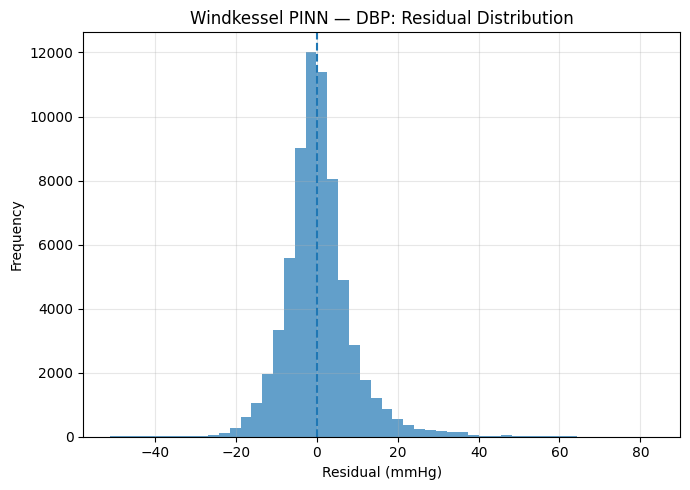

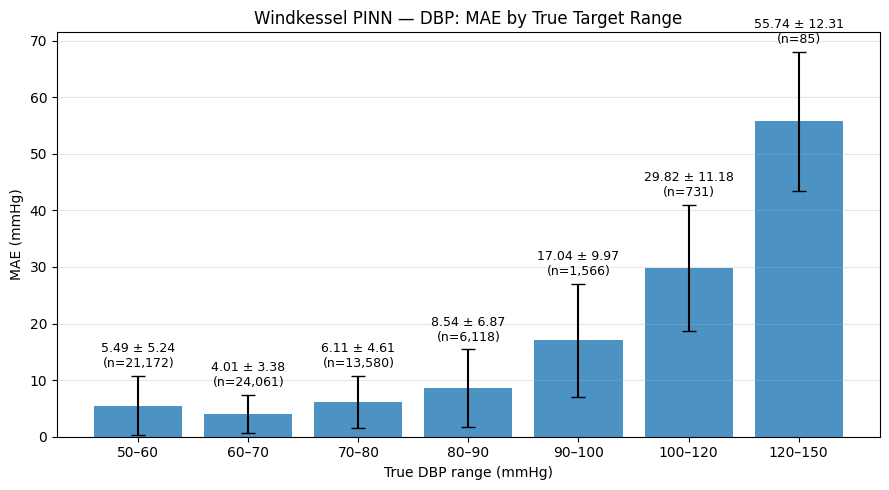

In [38]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.1
)

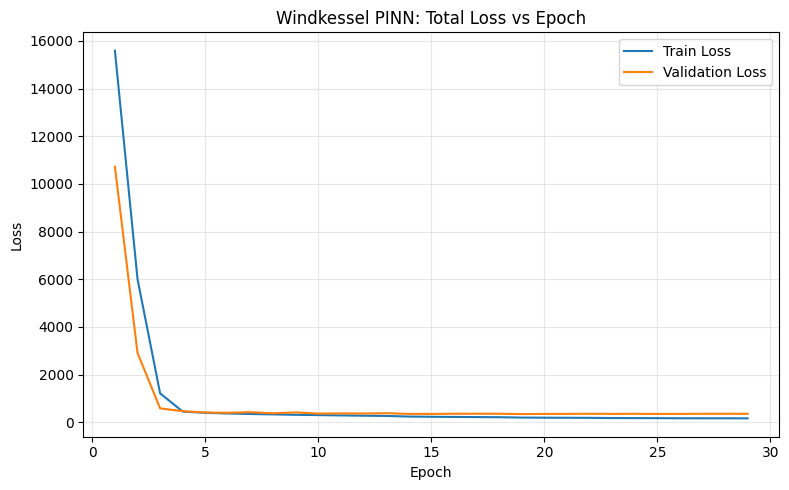

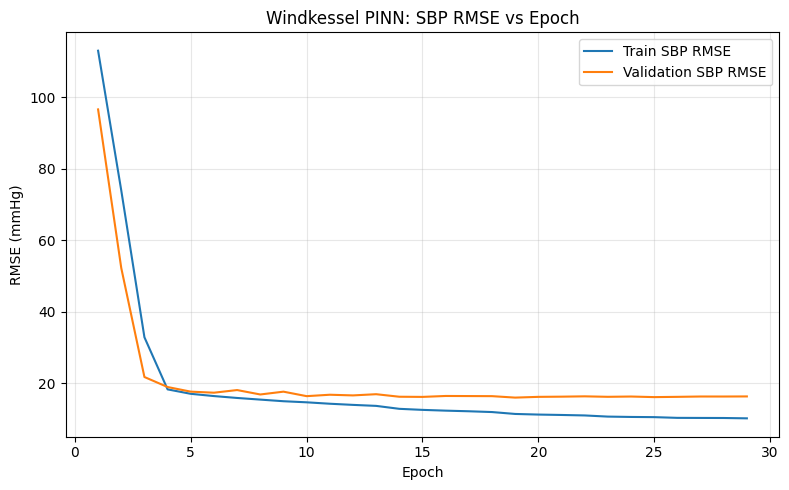

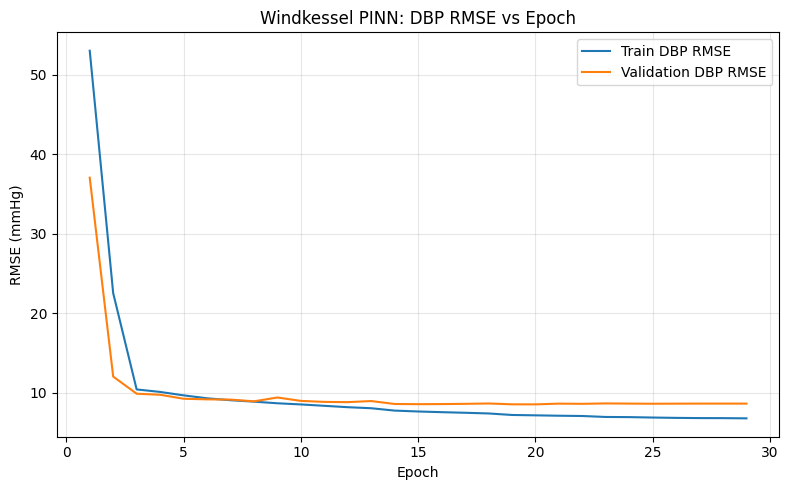

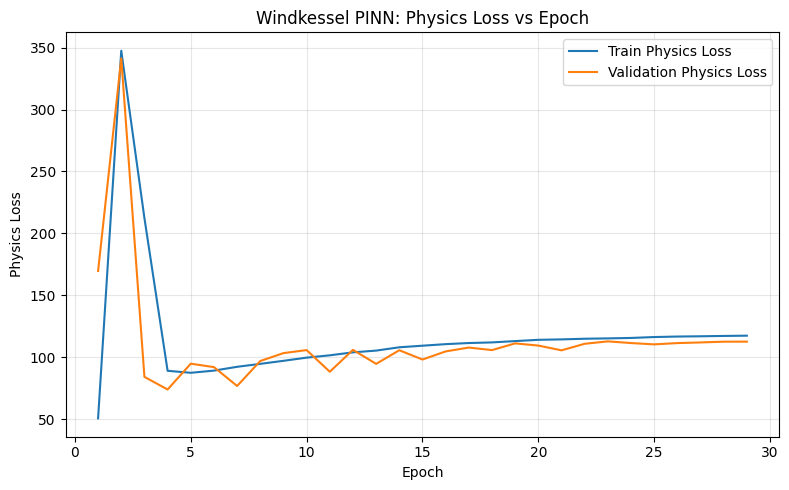

In [39]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16122.4504 | Train SBP MSE: 13136.4685 | Train DBP MSE: 2948.9602 | Train Phys: 37.0216 | Train RMSE: SBP=114.614, DBP=54.304 | Val Total: 10396.1336 | Val SBP MSE: 8903.1525 | Val DBP MSE: 1358.0215 | Val Phys: 134.9596 | Val RMSE: SBP=94.357, DBP=36.851 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6943.3755 | Train SBP MSE: 5982.5342 | Train DBP MSE: 787.4129 | Train Phys: 173.4283 | Train RMSE: SBP=77.347, DBP=28.061 | Val Total: 3723.1178 | Val SBP MSE: 3217.1129 | Val DBP MSE: 367.1754 | Val Phys: 138.8294 | Val RMSE: SBP=56.720, DBP=19.162 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1633.7005 | Train SBP MSE: 1347.8266 | Train DBP MSE: 182.7973 | Train Phys: 103.0765 | Train RMSE: SBP=36.713, DBP=13.520 | Val Total: 836.4499 | Val SBP MSE: 648.4553 | Val DBP MSE: 127.2418 | Val Phys: 60.7528 | Val RMSE: SBP=25.465, DBP=11.280 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 519.3593 | Train SBP MSE: 359.2398 | Train DBP MSE: 1

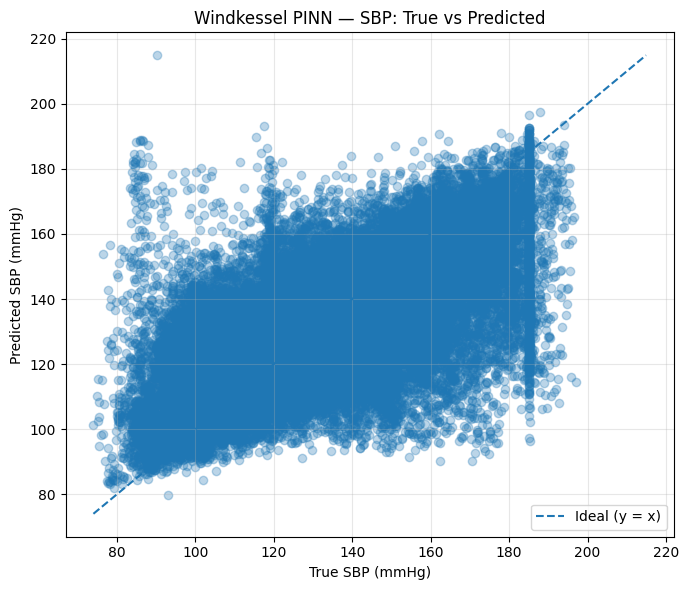

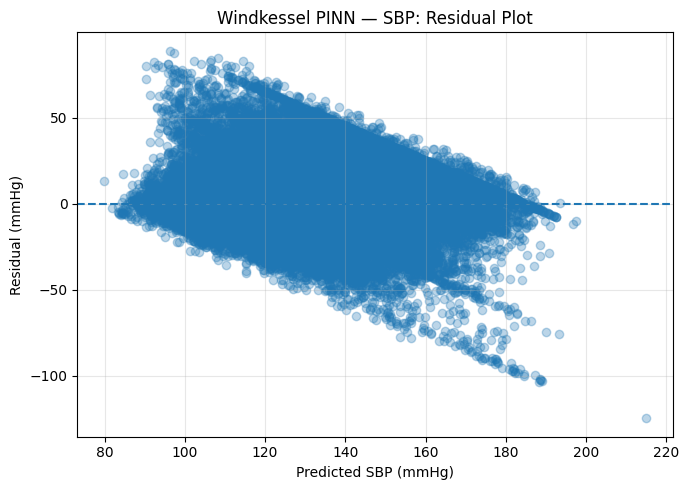

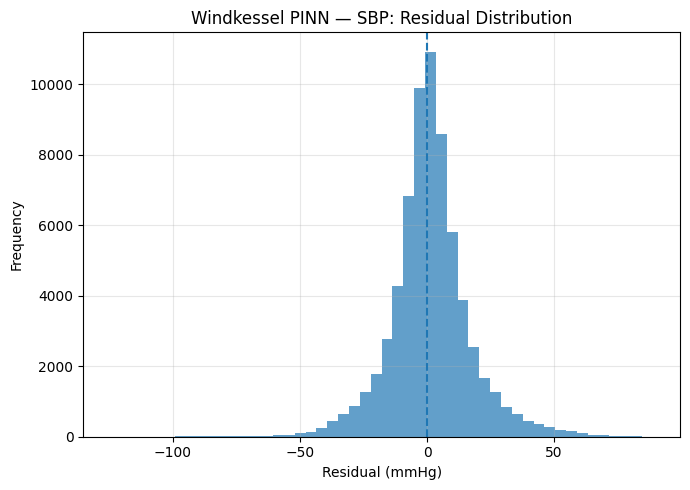

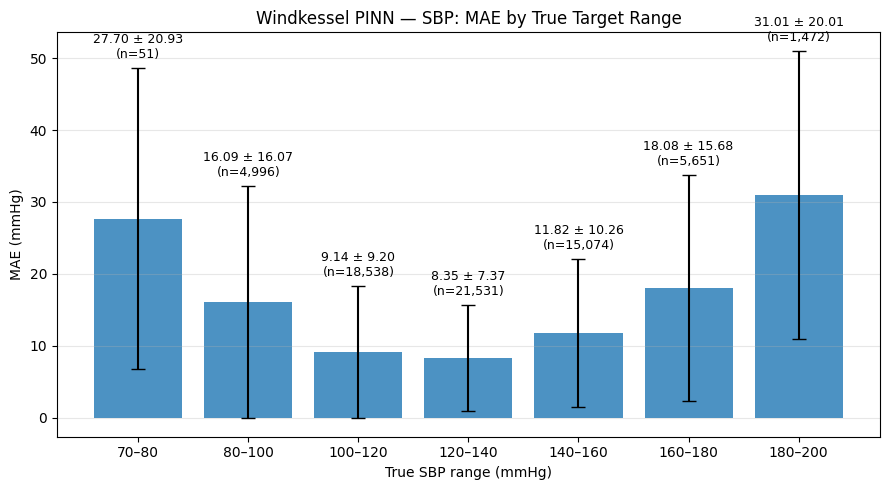


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.7572
MSE : 95.2033
R²  : 0.2324
MAE : 7.2143


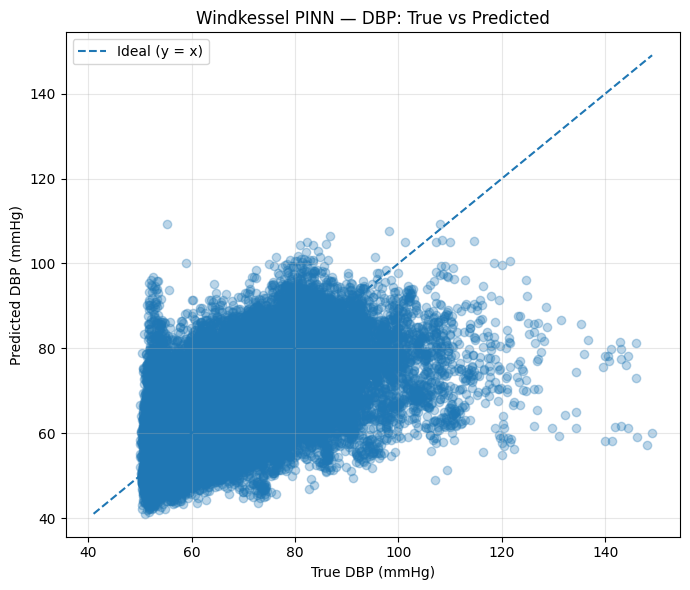

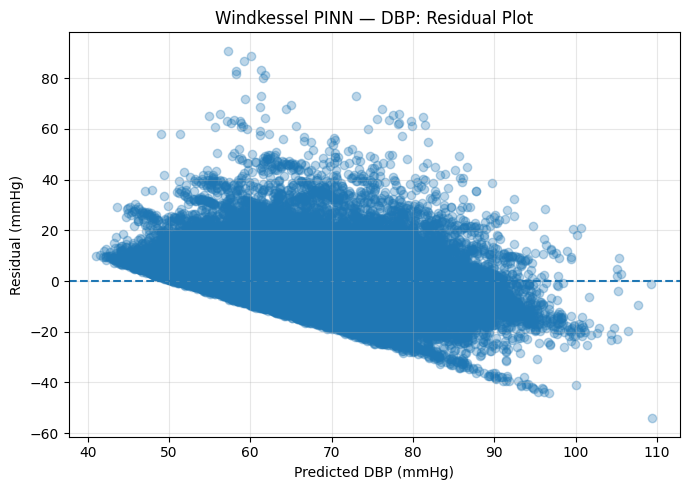

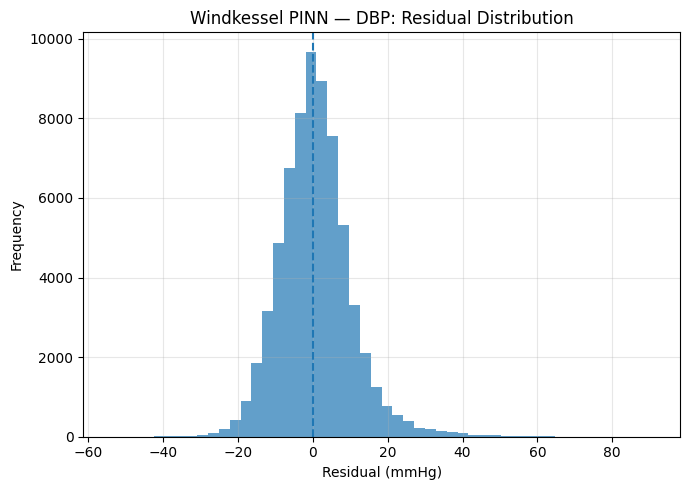

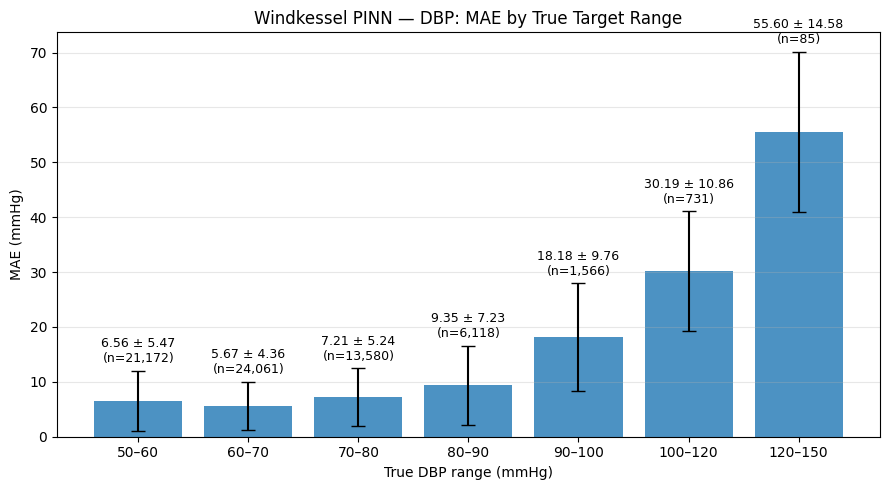

In [40]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=1
)

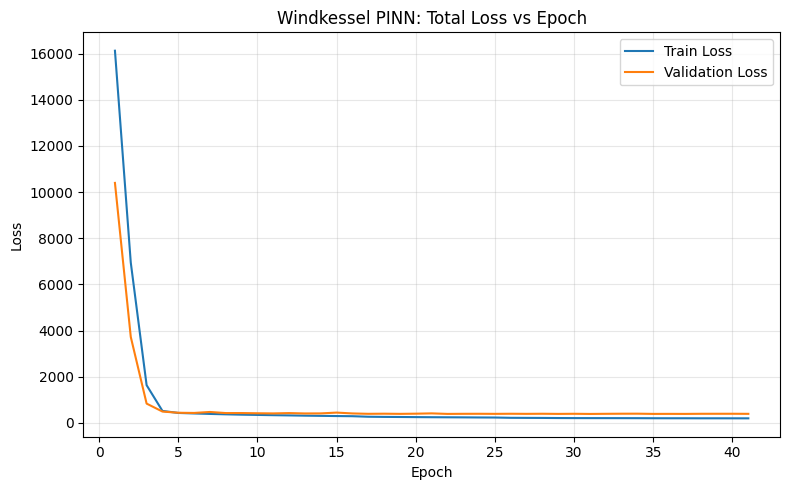

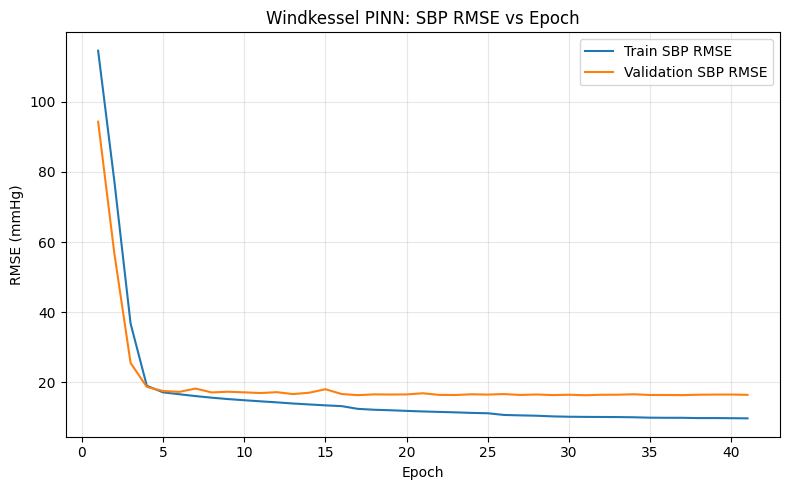

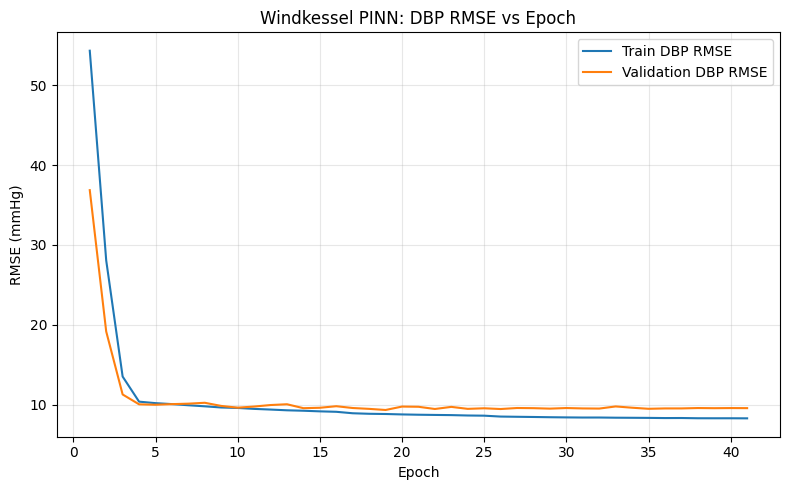

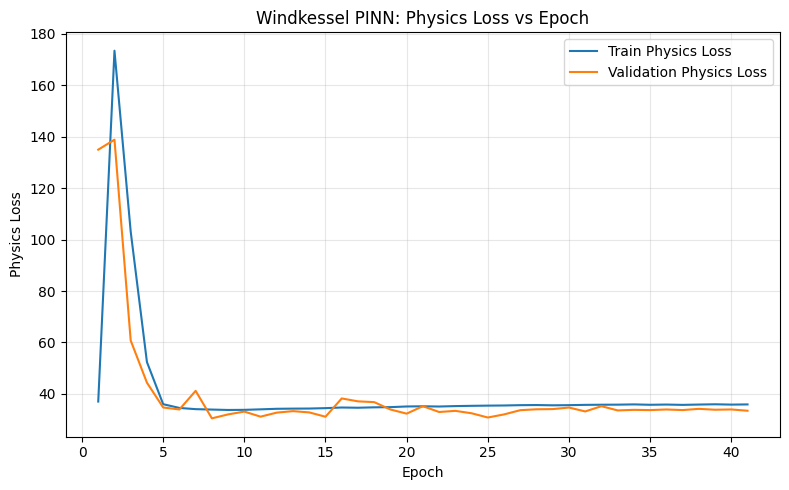

In [41]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16065.7349 | Train SBP MSE: 12841.8157 | Train DBP MSE: 3144.6134 | Train Phys: 7.9306 | Train RMSE: SBP=113.322, DBP=56.077 | Val Total: 10672.6087 | Val SBP MSE: 8591.5053 | Val DBP MSE: 1898.6159 | Val Phys: 18.2488 | Val RMSE: SBP=92.690, DBP=43.573 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6979.5141 | Train SBP MSE: 5549.9133 | Train DBP MSE: 1273.2039 | Train Phys: 15.6397 | Train RMSE: SBP=74.498, DBP=35.682 | Val Total: 3939.0635 | Val SBP MSE: 3011.7816 | Val DBP MSE: 820.3151 | Val Phys: 10.6967 | Val RMSE: SBP=54.880, DBP=28.641 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1502.1306 | Train SBP MSE: 1081.8420 | Train DBP MSE: 295.9065 | Train Phys: 12.4382 | Train RMSE: SBP=32.891, DBP=17.202 | Val Total: 766.0147 | Val SBP MSE: 516.5763 | Val DBP MSE: 162.8115 | Val Phys: 8.6627 | Val RMSE: SBP=22.728, DBP=12.760 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 621.9149 | Train SBP MSE: 355.2256 | Train DBP MSE: 147.91

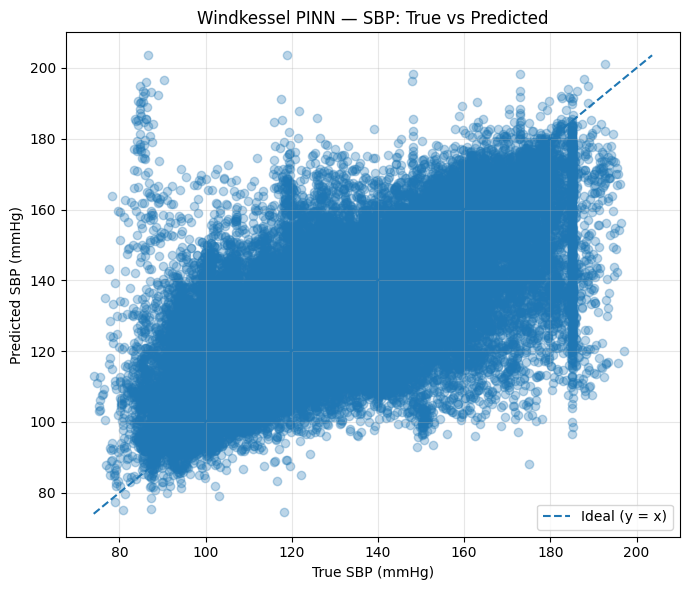

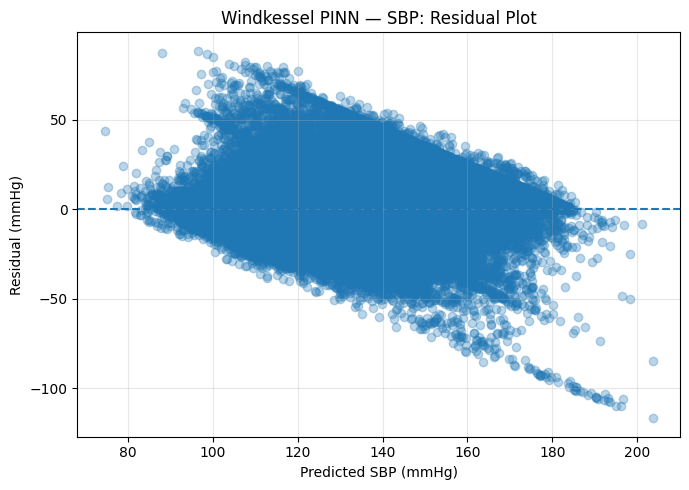

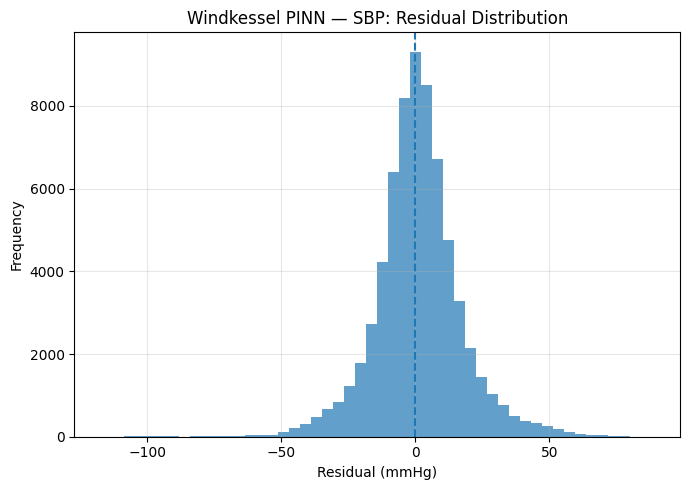

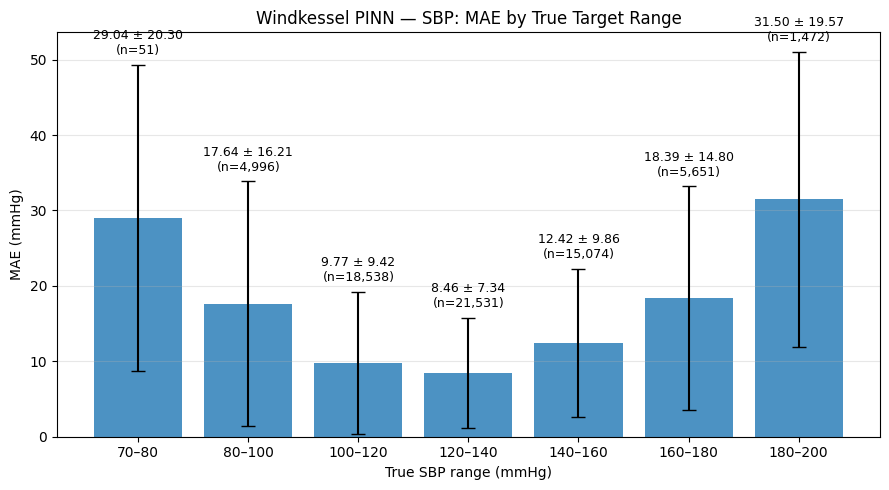


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 11.8464
MSE : 140.3370
R²  : -0.1315
MAE : 9.2010


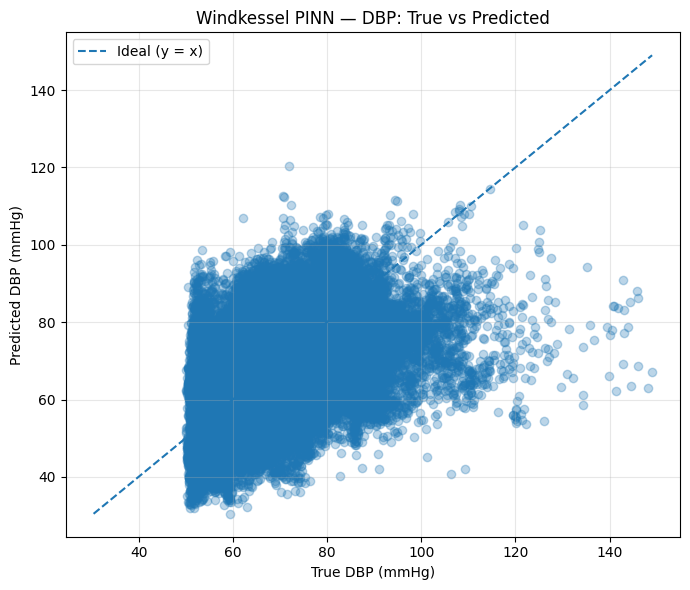

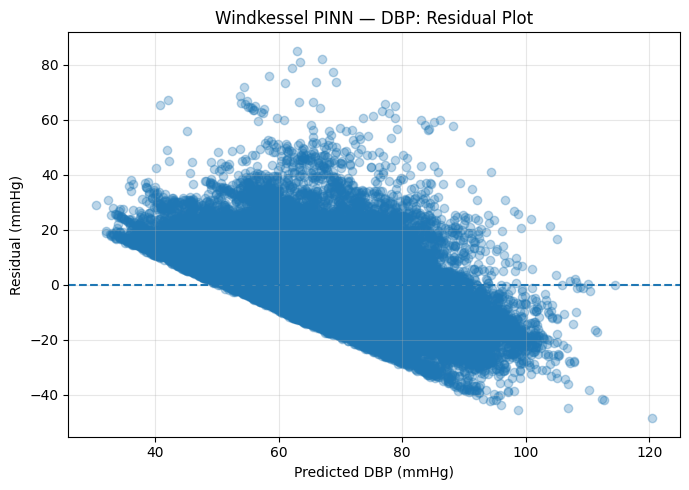

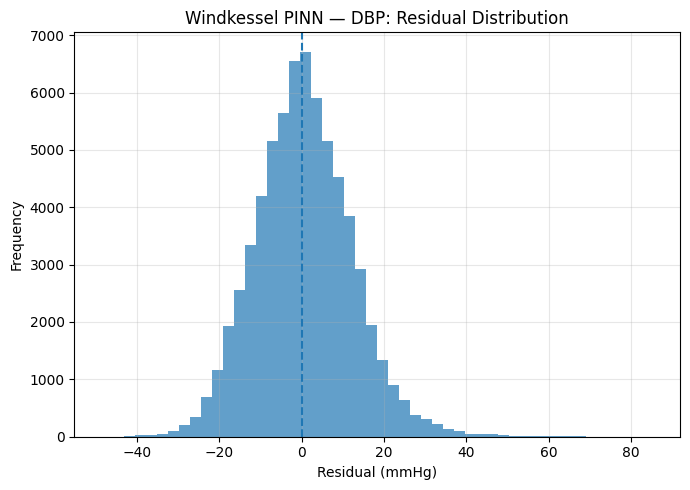

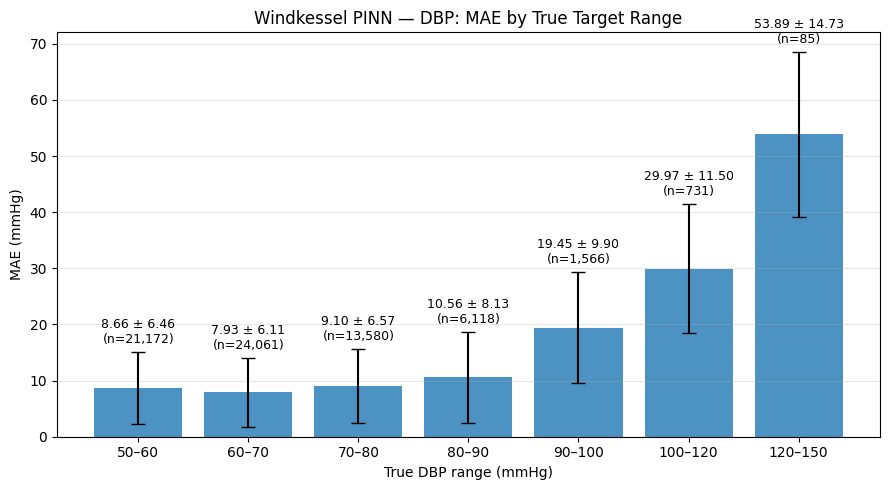

In [42]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=10
)

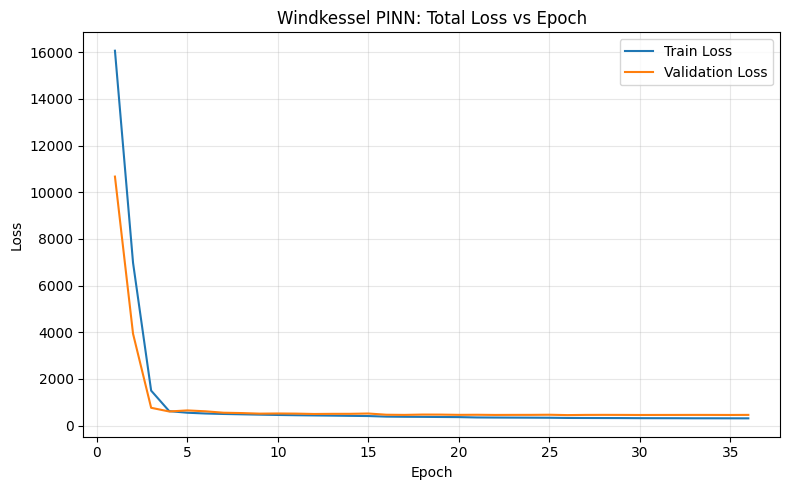

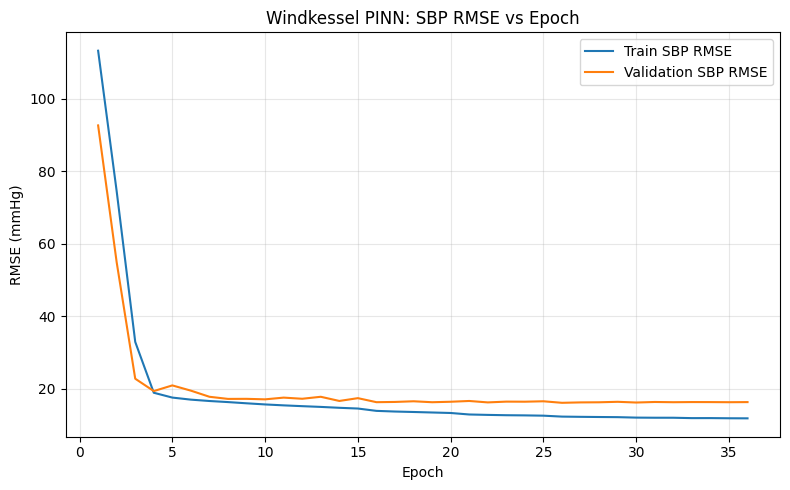

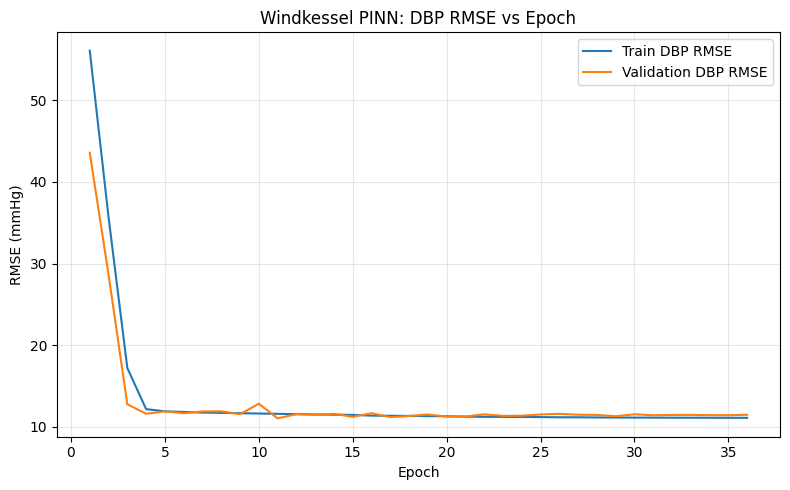

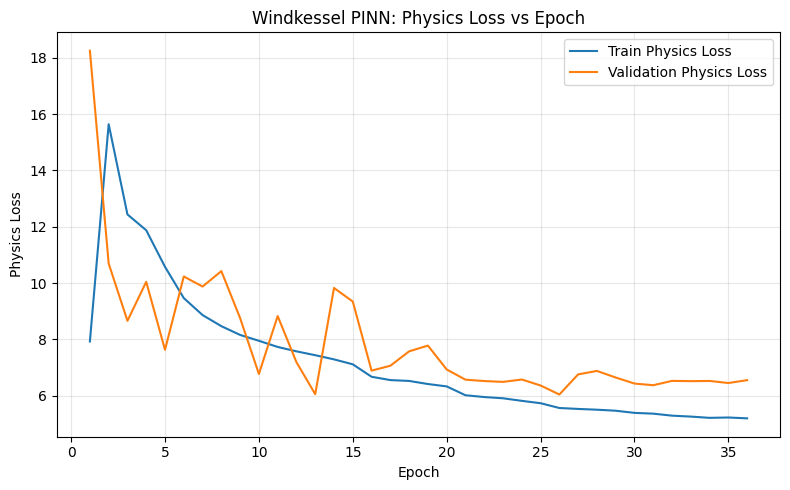

In [43]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16679.9552 | Train SBP MSE: 13173.9788 | Train DBP MSE: 3412.9162 | Train Phys: 0.9306 | Train RMSE: SBP=114.778, DBP=58.420 | Val Total: 11076.0882 | Val SBP MSE: 8746.0473 | Val DBP MSE: 2196.1132 | Val Phys: 1.3393 | Val RMSE: SBP=93.520, DBP=46.863 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 8392.9427 | Train SBP MSE: 6478.3663 | Train DBP MSE: 1685.6315 | Train Phys: 2.2894 | Train RMSE: SBP=80.488, DBP=41.056 | Val Total: 4134.9041 | Val SBP MSE: 3063.7607 | Val DBP MSE: 760.7133 | Val Phys: 3.1043 | Val RMSE: SBP=55.351, DBP=27.581 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 3424.5176 | Train SBP MSE: 2375.7250 | Train DBP MSE: 656.6840 | Train Phys: 3.9211 | Train RMSE: SBP=48.741, DBP=25.626 | Val Total: 2545.8571 | Val SBP MSE: 1683.4922 | Val DBP MSE: 459.4439 | Val Phys: 4.0292 | Val RMSE: SBP=41.030, DBP=21.435 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 1650.1830 | Train SBP MSE: 874.4703 | Train DBP MSE: 286.797

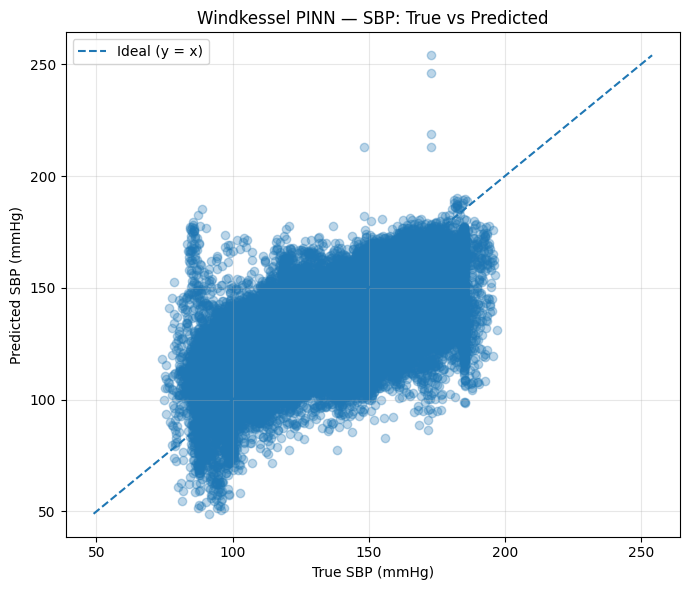

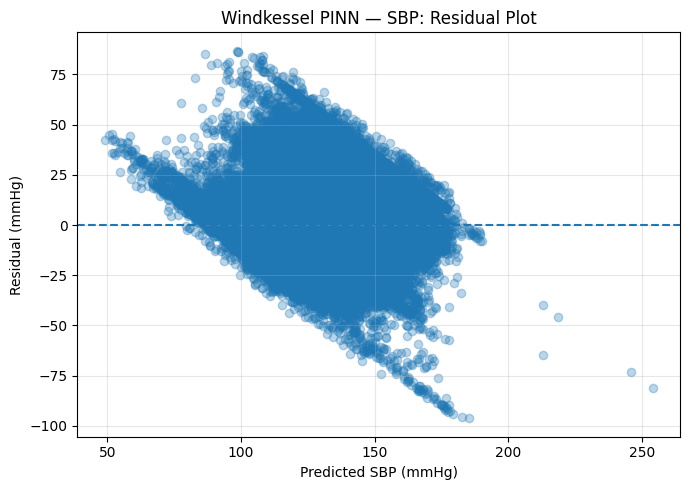

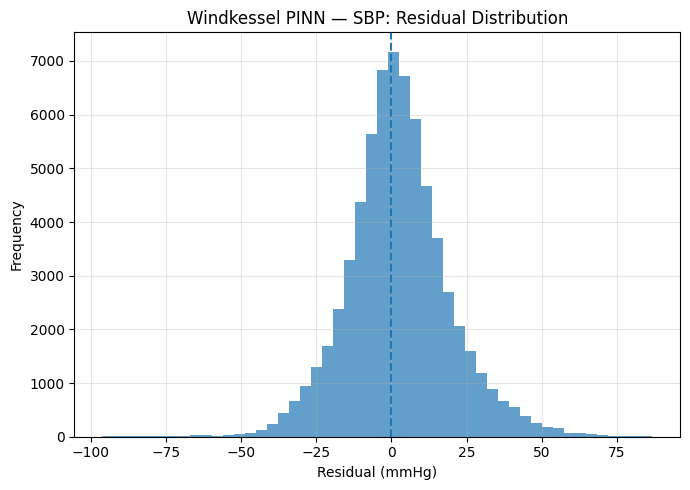

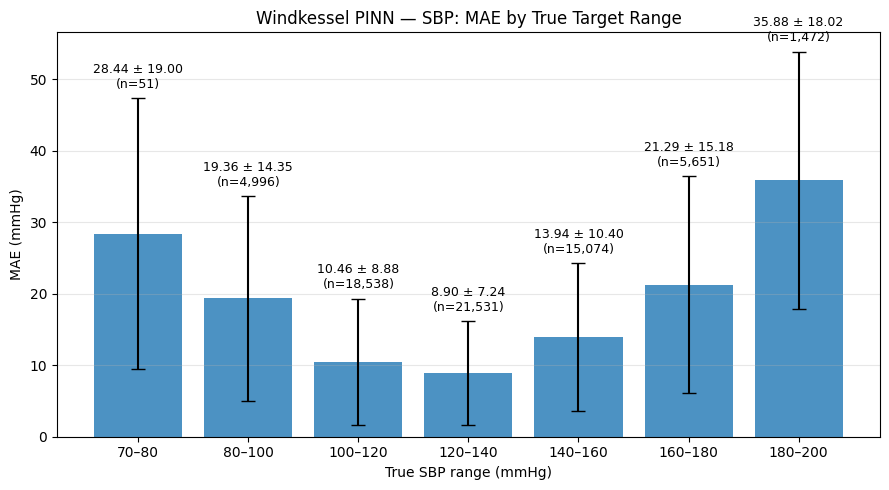


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 12.4750
MSE : 155.6266
R²  : -0.2547
MAE : 9.6705


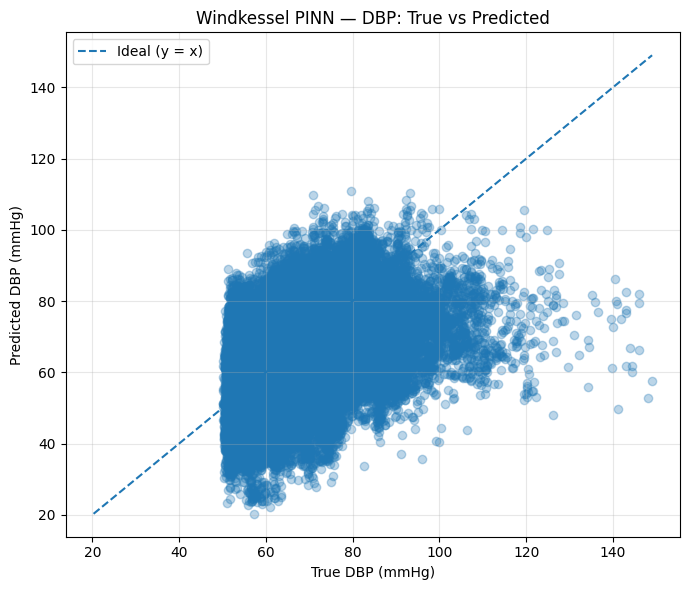

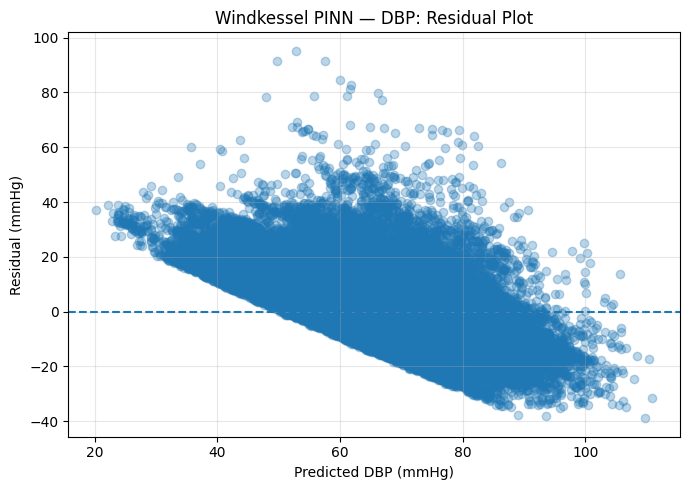

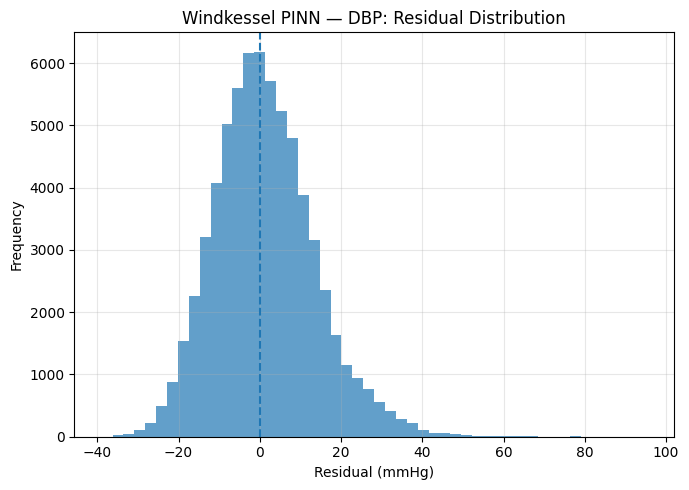

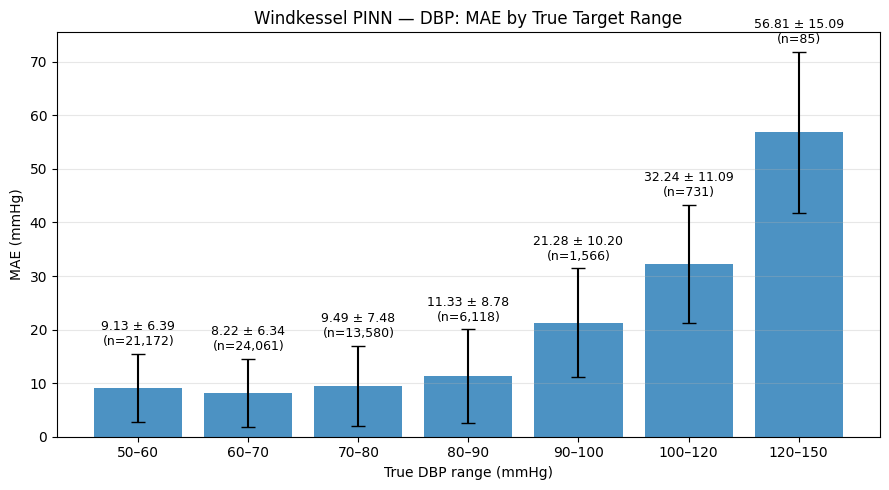

In [44]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=100
)

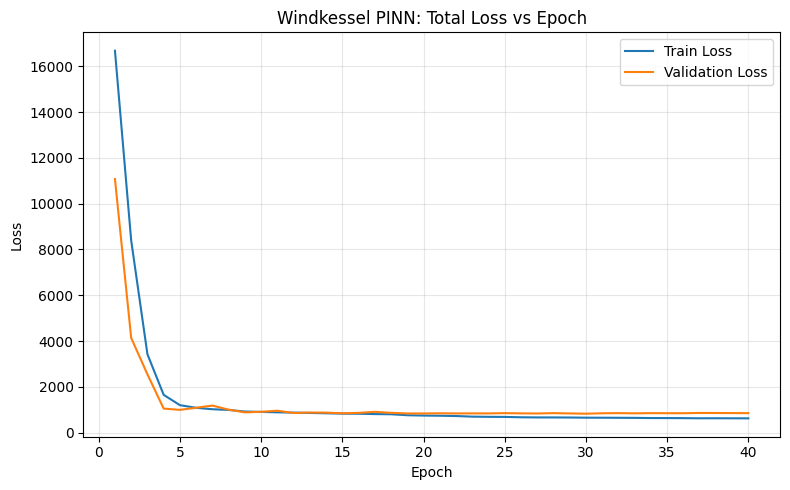

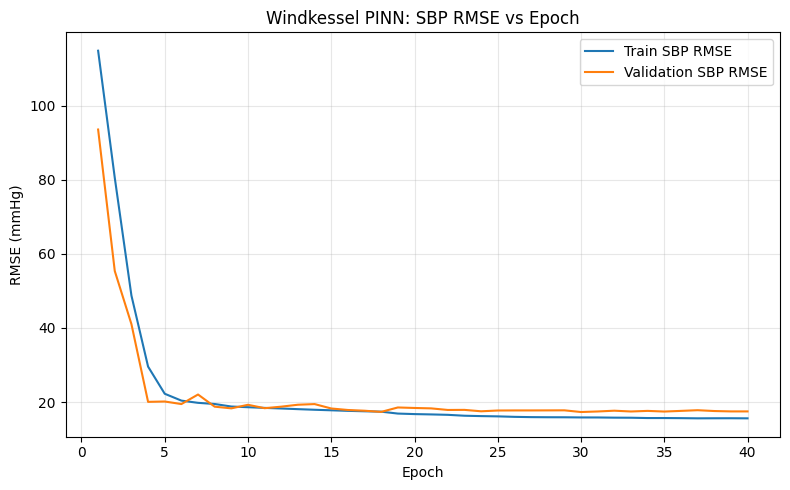

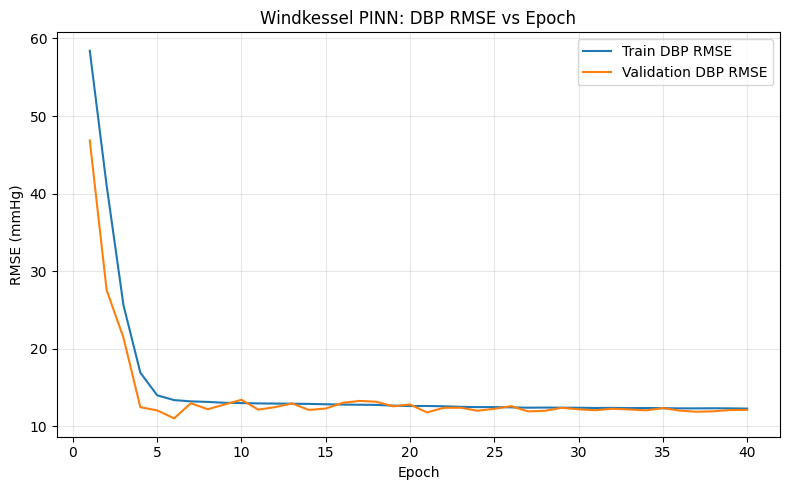

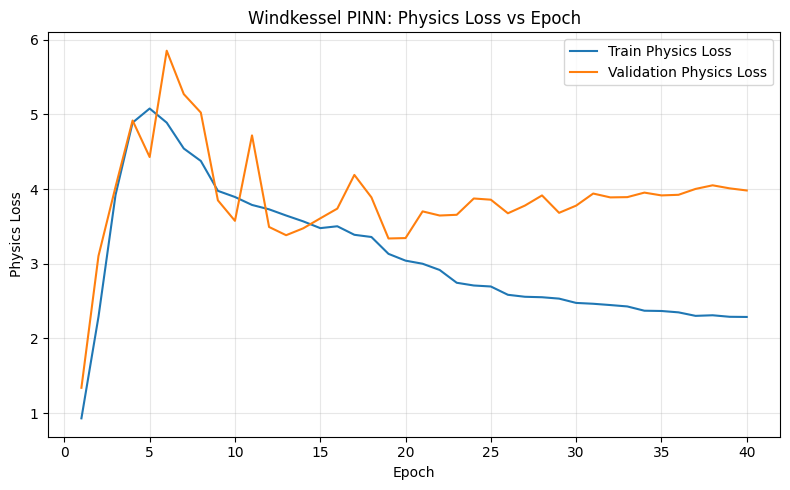

In [45]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)